# Quantum key distribution — BB84 end to end, entanglement-based protocols and the secret-key rate

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 14 — Quantum communication and cryptography*

## 1. Introduction and motivation

Alice and Bob want to encrypt their messages with the one-time pad of
[notebook 51](../ch14_quantum_communication_and_cryptography/51_secrecy_one_time_pad_and_authentication.ipynb), and
for that they need a long secret key: a string of uniformly random bits that both of them hold and that nobody else
knows. They are far apart. Between them runs an optical fibre that Eve may tap, cut, or replace by equipment of her
own, and a public line on which they can talk but on which Eve hears every word. On classical signals this problem
has no solution without assumptions on Eve's computing power, because Eve can copy every bit in transit and nobody
would notice. The task of this notebook is to show how the rules of quantum mechanics derived in
[notebook 52](../ch14_quantum_communication_and_cryptography/52_quantum_rules_channels_and_capacities.ipynb) solve it:
how Alice and Bob grow a secret key over a channel that Eve controls.

![BB84 from end to end: Alice sends random states in random bases through a channel that Eve controls, Bob measures in random bases, and four public steps (sifting, parameter estimation, error correction, privacy amplification) turn the raw data into a shared secret key](figures/bb84.svg)

**Figure 1.** The BB84 protocol from end to end. In the quantum stage Alice encodes a random bit in a randomly chosen
basis, $Z$ or $X$, and sends the qubit; Eve may do anything to it; Bob measures in a basis of his own random choice
(Section 4). The classical stage runs over the public authenticated channel, where Eve reads every message but cannot
change any. Alice and Bob keep the rounds in which their bases agree (sifting), estimate the error rate $Q$ on a
random sample and abort if it is too large (parameter estimation), remove the remaining errors with public parity
checks (error correction), and compress the corrected string with a random hash to remove whatever Eve may know
(privacy amplification). The final key has about $n\,[1-2h(Q)]$ bits for $n$ sifted rounds (Section 7).

**The idea.** Alice encodes each key bit in one of two bases chosen at random, and she reveals the basis only after
Bob has measured. While the qubit is in flight, Eve faces a state from a set of four nonorthogonal states and cannot
read it without disturbing it (notebook 52, Section 5). Every disturbance turns into errors between Alice's and Bob's
bits, so by comparing a random sample of their bits in public, Alice and Bob measure the error rate and from it bound
what Eve can know. Two classical steps from earlier in the chapter then finish the job: parity checks remove the
errors, and hashing removes Eve's partial knowledge. The same protocol can be run with entangled pairs, and in that
picture the security argument becomes transparent: a pair that is strongly correlated in two complementary bases,
$Z$ and $X$, whose states overlap with probability $1/2$, is close to a pure entangled state, and by monogamy such a pair leaves no room for Eve. A quantitative version of this
argument, an uncertainty relation with quantum memory, gives the secret-key rate $1-2h(Q)$, which is positive up to
an error rate of $11\,\%$.

### 1.1 Road map

* **Section 3** states what Alice and Bob want and what they have.
* **Section 4** builds the BB84 protocol with the engine: states and measurements, a vectorised simulation of many
  rounds, a worked table of ten rounds, sifting and error-rate estimation, error correction with the parity checks of
  notebook 50, privacy amplification with the random hash of notebook 51, and the final key.
* **Section 5** derives the error rate $Q=1/4$ and Eve's information of $1/2$ bit of the intercept–resend attack,
  simulates it, and places it next to the probe attack of notebook 52.
* **Section 6** turns to entangled pairs: the BBM92 protocol, the source-replacement picture that shows its
  equivalence with BB84, and Ekert's protocol with the CHSH test.
* **Section 7** derives the secret-key rate: bit and phase errors, the Devetak–Winter rate, the uncertainty relation
  with quantum memory, the rate $1-2h(Q)$ and its threshold, the Werner-pair version, and a comparison with the key
  that the simulated protocol actually extracts at several error rates.
* **Section 8** gives an outlook on device-independent key distribution and its rate.
* **Section 9** lists the practical issues: loss, multi-photon pulses and decoy states, and attacks on detectors.

### What you will learn

*Physics and information*

* how BB84 turns random bases, sifting and public discussion into a shared secret key;
* why intercepting and resending causes a $25\,\%$ error rate, and how Eve's information grows with the error rate;
* why a BB84 sender is equivalent to a source of entangled pairs, and what the CHSH test adds;
* the difference between bit errors and phase errors, and why phase errors bound Eve's knowledge;
* the key rate $r=H(Z_A\vert E)-H(Z_A\vert B)$, the uncertainty relation $H(Z_A\vert E)+H(X_A\vert B)\geq1$, and
  the BB84 rate $1-2h(Q)$ with its $11\,\%$ threshold;
* what device independence means, and which imperfections of real devices have been exploited.

*Numerical methods*

* a vectorised Monte Carlo simulation of protocol rounds with the engine's measurement and noise functions;
* conditional entropies with quantum side information from reduced density matrices;
* statistical error bars on an estimated error rate, and their effect on the key length.

*Implementation practice*

* states prepared with gates, measurements with `measure_qubit`, noise with `apply_kraus_mcwf`, all compiled with
  `jax.jit` and mapped over rounds with `jax.vmap`;
* the parity-check reconciliation of notebook 50 and the random hash of notebook 51 reused on simulated keys;
* wrong controls that must fail: an Eve who knows the basis, a classically correlated source, uncorrected keys fed to
  the hash, and the uncertainty relation applied to a single party.

### Prerequisites

* [Notebook 50](../ch14_quantum_communication_and_cryptography/50_information_entropy_and_noisy_channels.ipynb):
  entropy, the binary entropy $h(q)$, conditional entropy and mutual information (Sections 3–4), and the parity-check
  reconciliation with its cost of about $h(Q)$ revealed bits per key bit (Section 6.3).
* [Notebook 51](../ch14_quantum_communication_and_cryptography/51_secrecy_one_time_pad_and_authentication.ipynb): the
  threat model (Section 3), why the public channel must be authenticated (Section 8), and privacy amplification by
  random linear hashing (Section 9).
* [Notebook 52](../ch14_quantum_communication_and_cryptography/52_quantum_rules_channels_and_capacities.ipynb):
  nonorthogonal states and the Helstrom bound (Section 3), information gain implies disturbance with the probe attack
  (Section 5), and monogamy with the von Neumann entropy and the quantum mutual information (Section 6).
* [Notebook 19](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb): the Bell states, the CHSH
  inequality and its quantum violation (Sections 3–8), and Werner states (Section 11).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

A qubit is a tensor of shape $(2,)$ and two qubits a tensor of shape $(2,2)$; density matrices are density tensors,
as in notebook 07. Alice prepares her states with `apply_gate`, Eve and Bob measure with `measure_qubit`, which
returns
a random outcome and the collapsed state, and channel noise acts with `apply_kraus_mcwf`, which applies one randomly
chosen Kraus operator to a pure state, so that the average over many rounds is the channel. The helper cell repeats
the entropy functions of notebook 50, the reconciliation of notebook 50, Section 6.3, and the random linear hash of
notebook 51, Section 9.2, in compact form. As in the earlier notebooks of the chapter, experiment $i$ draws its random
numbers from its own key `jax.random.fold_in(MASTER, i)`.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def controlled(U):
    """Controlled-U = |0><0| (x) 1 + |1><1| (x) U  as a 4x4 block matrix (control = first qubit)."""
    return jnp.block([[jnp.eye(2, dtype=CDTYPE), jnp.zeros((2, 2), CDTYPE)],
                      [jnp.zeros((2, 2), CDTYPE), U]])


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def trace_distance(rho, sigma):
    """D = (1/2)||rho - sigma||_1 = (1/2) sum_i |eigenvalue_i(rho - sigma)|  (Hermitian difference)."""
    return 0.5 * jnp.sum(jnp.abs(jnp.linalg.eigvalsh(rho - sigma)))


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def measure_qubit(key, psi, q, basis="Z"):
    """Projective measurement of qubit q in the eigenbasis of X, Y or Z.  Returns (outcome, post-state).

    MATH   Born rule      p(0) = <psi|P0_q|psi> = (rho_q)[0,0]          (only the 1-qubit RDM is needed)
           collapse       |psi> -> P_m|psi> / sqrt(p(m))
           other bases    measuring P = U^dag Z U  ==  rotate with U, measure Z, rotate back with U^dag
                          (X: U = H;   Y: U = H S^dag).
    outcome 0 <-> eigenvalue +1,   outcome 1 <-> eigenvalue -1.
    JAX    no Python `if` on random data: `jnp.where` selects the projector, so the function is
           jit/vmap-able (vmap over keys = many independent shots).
    """
    U = _BASIS_ROT[basis]
    psi = apply_gate(psi, U, [q])
    p0 = jnp.real(rdm(psi, [q])[0, 0])
    outcome = (jax.random.uniform(key) >= p0).astype(jnp.int32)
    proj = jnp.where(outcome == 0, P0, P1)
    psi = apply_gate(psi, proj, [q])
    psi = psi / jnp.linalg.norm(psi)
    return outcome, apply_gate(psi, U.conj().T, [q])


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def apply_kraus_mcwf(key, psi, kraus, qubits):
    """Apply a channel to a PURE state stochastically (quantum trajectory / Monte-Carlo wave function).

    MATH   choose branch m with probability  p_m = ||K_m psi||^2 = Tr(K_m rho_A K_m^dag)
           then  |psi> -> K_m|psi> / sqrt(p_m).
           Averaging |psi><psi| over many trajectories gives exactly  sum_m K_m rho K_m^dag.
    WHY    memory O(2^N) instead of O(4^N): open systems at the price of closed ones (times #trajectories,
           which are embarrassingly parallel -> jax.vmap over keys).
    IMPLEMENTATION   probabilities come from the SMALL reduced density matrix (einsum "mab,bc,mac->m");
           `K[m]` with a traced integer m is a gather, so everything stays jit-compatible.
    """
    K = jnp.asarray(kraus, dtype=CDTYPE)
    r = rdm(psi, qubits)
    probs = jnp.real(jnp.einsum("mab,bc,mac->m", K, r, jnp.conj(K)))
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers (entropies as in notebook 50, reconciliation as in notebook 50, hashing as in notebook 51)
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})

MASTER = jax.random.PRNGKey(53)          # one master key per run; experiment i uses fold_in(MASTER, i)


def key_for(i):
    """Independent key for experiment number i."""
    return jax.random.fold_in(MASTER, i)


def numpy_rng(i):
    """numpy Generator seeded from experiment key i (for public random choices: samples, permutations, hashes)."""
    return np.random.default_rng(int(jax.random.randint(key_for(i), (), 0, 2**31 - 1)))


def h2(q):
    """Binary entropy h(q) in bits (notebook 50, Eq. (4)); scalars and arrays, 0 log 0 = 0."""
    q = np.asarray(q, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        out = -q * np.log2(np.where(q > 0, q, 1.0)) - (1 - q) * np.log2(np.where(q < 1, 1 - q, 1.0))
    return out if out.ndim else float(out)


def shannon(probs):
    """Shannon entropy in bits of a probability vector or table (notebook 50, Eq. (2))."""
    p = np.asarray(probs, dtype=float).ravel()
    p = p[p > 1e-15]
    return float(-(p * np.log2(p)).sum()) + 0.0


def mutual_info(table):
    """Mutual information I(X:Y) in bits of a joint table of counts or probabilities (notebook 50, Eq. (10))."""
    t = np.asarray(table, dtype=float)
    t = t / t.sum()
    return shannon(t.sum(1)) + shannon(t.sum(0)) - shannon(t)


def binom_se(p, n):
    """Standard error of an observed frequency p from n independent trials."""
    return float(np.sqrt(max(p * (1 - p), 1e-300) / n))


_vn_entropy = jax.jit(von_neumann_entropy)


def S_vn(rho_mat):
    """Von Neumann entropy S(rho) = -Tr rho log2 rho of a density MATRIX, as a Python float."""
    return float(_vn_entropy(jnp.asarray(rho_mat, dtype=CDTYPE))) + 0.0


# ---- error correction: block parities + binary search in shuffled passes (notebook 50, Section 6.3) ----------
def parity(v):
    return int(np.sum(v) % 2)


def binary_search(a_blk, b_blk):
    """Locate one error in a block whose parities differ; returns (index, number of parities revealed)."""
    lo, hi, revealed = 0, len(a_blk), 0
    while hi - lo > 1:
        mid = (lo + hi) // 2
        revealed += 1                                          # Alice announces the parity of a[lo:mid]
        lo, hi = (lo, mid) if parity(a_blk[lo:mid]) != parity(b_blk[lo:mid]) else (mid, hi)
    return lo, revealed


def reconcile(a, b, L, passes, perm_rng):
    """Shuffled passes of block parities + binary search. Returns (corrected b, number of parities revealed)."""
    b = b.copy(); n = len(a); leak = 0
    for p in range(passes):
        perm = np.arange(n) if p == 0 else perm_rng.permutation(n)            # public random permutation
        Lp = L * 2**p
        for start in range(0, n, Lp):
            idx = perm[start:start + Lp]
            leak += 1                                                          # block parity
            if parity(a[idx]) != parity(b[idx]):
                j, r = binary_search(a[idx], b[idx])
                leak += r
                b[idx[j]] ^= 1
    return b, leak


# ---- privacy amplification: k = G x mod 2 with a public random binary matrix G (notebook 51, Eq. (15)) -------
def random_hash(x, ell, seed, chunk=256):
    """MATH  k = G x (mod 2), G a uniformly random ell x n binary matrix generated from the public `seed`.

    IMPLEMENTATION  G is generated in blocks of `chunk` rows and multiplied in floating point with RDTYPE (sums
    <= n < 2^24 are exact in single and double precision), so memory stays O(chunk * n). Alice and Bob call it
    with the same seed and get the same G.
    """
    g = np.random.default_rng(seed)
    xf = np.asarray(x, dtype=RDTYPE)
    out = [np.zeros(0)]
    for start in range(0, ell, chunk):
        G = g.integers(0, 2, (min(chunk, ell - start), len(x)), dtype=np.uint8).astype(RDTYPE)
        out.append((G @ xf) % 2)
    return np.concatenate(out).astype(np.uint8)


KET0, KET1 = product_state("0"), product_state("1")
KETP, KETM = product_state("+"), product_state("-")

## 3. The task and the resources

Alice and Bob want a key with three properties: their two copies agree, the bits are uniformly random, and Eve knows
essentially nothing about them. They have two resources.

* A **quantum channel** from Alice to Bob, for example an optical fibre that carries single photons. Eve controls it
  completely: she may measure the photons, entangle them with probes of her own, or replace them.
* A **public authenticated classical channel** (notebook 51, Section 3.2). Eve reads every message on it but cannot
  change, insert or suppress messages. Authentication costs a short secret key shared in advance (notebook 51,
  Section 8.3), so the protocol grows a key from a shorter one.

The protocol may **abort**: if Alice and Bob see too much disturbance, they output no key. Eve can always force an
abort, for instance by cutting the fibre, and no protocol can prevent that. What she must never achieve is a key that
Alice and Bob accept and she knows. Security is a statement about this second event only.

## 4. The BB84 protocol

### 4.1 Four states in two bases

The first protocol of quantum key distribution was proposed by Bennett and Brassard in 1984 and is called BB84 after
them. It uses the four states of two bases,

$$\begin{aligned}
Z\ \text{basis:}&\quad\text{bit }0\to\vert0\rangle,\qquad\text{bit }1\to\vert1\rangle,\\
X\ \text{basis:}&\quad\text{bit }0\to\vert+\rangle=\tfrac{1}{\sqrt2}(\vert0\rangle+\vert1\rangle),\qquad
\text{bit }1\to\vert-\rangle=\tfrac{1}{\sqrt2}(\vert0\rangle-\vert1\rangle).
\end{aligned} \tag{1}$$

Alice prepares the state for bit $a$ in basis $x$ ($x=0$ for $Z$, $x=1$ for $X$) as
$\vert\psi_{a,x}\rangle=H^x X^a\vert0\rangle$: an $X$ gate writes the bit, and a Hadamard gate $H$ turns the $Z$
basis into the $X$ basis. Bob measures in basis $y$; a measurement in the $X$ basis is a Hadamard followed by a
$Z$ measurement, since $H\vert\pm\rangle$ equals $\vert0\rangle$ or $\vert1\rangle$. The Born rule gives the
probability that Bob finds bit $b$:

$$P(b\,\vert\,a,x,y)=\vert\langle b\vert H^yH^xX^a\vert0\rangle\vert^2=\begin{cases}\delta_{ab}, & y=x,\\
\tfrac12, & y\neq x.\end{cases} \tag{2}$$

States of the same basis are orthogonal, so a measurement in the right basis returns Alice's bit with certainty.
States of different bases have overlap $\vert\langle0\vert+\rangle\vert^2=1/2$, so a measurement in the wrong basis
returns a uniformly random bit and carries no information about $a$. The next cell prepares the four states with
gates, checks them against the engine's product states, and evaluates Eq. (2) for all sixteen combinations.

In [4]:
# ==============================================================================
# Eqs. (1)-(2): the four BB84 states prepared with gates, and Bob's outcome probabilities
# ==============================================================================
def prepare(a, x):
    """Eq. (1): |psi_{a,x}> = H^x X^a |0>  (a = bit, x = 0 for the Z basis, 1 for the X basis).
    a and x may be traced integers: jnp.where selects the gate, so the function can be jitted and vmapped."""
    psi = apply_gate(KET0, jnp.where(a == 1, X, I2), [0])
    return apply_gate(psi, jnp.where(x == 1, H, I2), [0])


for (a, x), ref, name in [((0, 0), KET0, "|0>"), ((1, 0), KET1, "|1>"), ((0, 1), KETP, "|+>"), ((1, 1), KETM, "|->")]:
    assert float(jnp.max(jnp.abs(prepare(a, x) - ref))) < TOL
    print(f"bit {a}, basis {'ZX'[x]}: H^{x} X^{a}|0> = {name}")

print("\nP(Bob finds b = a)   Bob: Z     X")
for a in (0, 1):
    for x in (0, 1):
        row = []
        for y in (0, 1):
            psi_rot = apply_gate(prepare(a, x), jnp.where(y == 1, H, I2), [0])           # rotate to Bob's basis
            row.append(float(jnp.abs(psi_rot[a]) ** 2))                                  # Born rule, Eq. (2)
            assert abs(row[-1] - (1.0 if x == y else 0.5)) < TOL
        print(f"  Alice bit {a}, basis {'ZX'[x]}:   {row[0]:.3f}  {row[1]:.3f}")

bit 0, basis Z: H^0 X^0|0> = |0>
bit 1, basis Z: H^0 X^1|0> = |1>
bit 0, basis X: H^1 X^0|0> = |+>
bit 1, basis X: H^1 X^1|0> = |->

P(Bob finds b = a)   Bob: Z     X
  Alice bit 0, basis Z:   1.000  0.500
  Alice bit 0, basis X:   0.500  1.000
  Alice bit 1, basis Z:   1.000  0.500
  Alice bit 1, basis X:   0.500  1.000


Same basis: Bob finds Alice's bit with probability $1$; different bases: with probability $1/2$, a coin toss. This
table is the whole physics of BB84, and everything below is bookkeeping around it.

### 4.2 The protocol and a simulation of its rounds

The protocol has a quantum stage and a classical stage (Figure 1).

1. **Preparation.** In each round Alice draws a random bit $a$ and a random basis $x$ and sends
   $\vert\psi_{a,x}\rangle$.
2. **Measurement.** Bob draws his own random basis $y$, independently of Alice, measures, and records his bit $b$.
3. **Sifting.** After all qubits have arrived, Alice and Bob announce their bases, but not their bits, and keep only
   the rounds with $x=y$, about half of them. The kept bits form the **sifted key**.
4. **Parameter estimation.** They choose a random subset of the sifted rounds, announce those bits and compare them.
   The fraction of disagreements is the **quantum bit error rate** (QBER) $Q$. The announced bits are discarded.
5. **Abort test.** If $Q$ exceeds a threshold, they abort.
6. **Error correction.** Public parity checks remove the remaining errors (notebook 50, Section 6.3).
7. **Privacy amplification.** A public random hash shortens the key and removes Eve's partial knowledge
   (notebook 51, Section 9).

The order of the steps matters. The bases are announced only after Bob has measured, so while the qubit is in
flight nobody except Alice knows its basis. If Eve knew the basis, she could measure in it, learn the bit, and
resend an exact copy without causing any error; Section 5.2 runs this as a wrong control.

The function `one_round` below is one round of the quantum stage as a circuit. Alice prepares her state with
`prepare`; Eve, with probability $f$, measures in a basis $x_E$ of her own choice and passes on the collapsed state
(the intercept–resend attack of Section 5); the channel applies depolarising noise of strength $p_{\rm dep}$
(notebook 52, Section 8.2) through `apply_kraus_mcwf`; Bob measures in his basis. A measurement in a basis given by a
traced bit is done by measuring in both bases with the same random key and selecting one result with `jnp.where`,
which keeps the function free of Python branches. `simulate_rounds` compiles the round with `jax.jit` and maps it
over many independent keys with `jax.vmap` (notebook 01), so that, once compiled, $10^5$ rounds take a fraction of
a second.

For the depolarising channel two of the three Pauli errors flip a bit in either basis ($X$ and $Y$ flip a $Z$ bit,
$Z$ and $Y$ flip an $X$ bit), so without Eve the error rate of the sifted rounds is

$$Q=\tfrac23\,p_{\rm dep}. \tag{3}$$

The cell ends with a check of Eqs. (2) and (3) on $10^5$ rounds.

In [5]:
# ==============================================================================
# One round of BB84 with the engine; many rounds with jit + vmap
# ==============================================================================
ROUND_FIELDS = ("a", "x", "y", "b", "xE", "e", "attacked")      # Alice bit/basis, Bob basis/bit, Eve basis/outcome/flag


def measure_in(key, psi, basis):
    """Measure qubit 0 of psi in the Z basis (basis = 0) or the X basis (basis = 1); returns (bit, collapsed state)."""
    oz, pz = measure_qubit(key, psi, 0, "Z")
    ox, px = measure_qubit(key, psi, 0, "X")
    return jnp.where(basis == 1, ox, oz), jnp.where(basis == 1, px, pz)


def one_round(key, f, p_dep, eve_knows_basis):
    """One BB84 round: preparation, intercept-resend with probability f, depolarising noise p_dep, Bob's measurement.
    Returns the integers (a, x, y, b, xE, e, attacked)."""
    ka, kx, ky, kxe, kf, ke, kn, kb = jax.random.split(key, 8)
    a = jax.random.bernoulli(ka).astype(jnp.int32)                     # Alice's bit
    x = jax.random.bernoulli(kx).astype(jnp.int32)                     # Alice's basis
    y = jax.random.bernoulli(ky).astype(jnp.int32)                     # Bob's basis, independent of x
    xE = x if eve_knows_basis else jax.random.bernoulli(kxe).astype(jnp.int32)
    attacked = jax.random.uniform(kf) < f
    psi = prepare(a, x)
    e, psi_eve = measure_in(ke, psi, xE)                               # Eve measures ...
    psi = jnp.where(attacked, psi_eve, psi)                            # ... and resends the collapsed state
    psi = apply_kraus_mcwf(kn, psi, kraus_depolarizing(p_dep), [0])    # channel noise, one Kraus branch per round
    b, _ = measure_in(kb, psi, y)                                      # Bob's measurement
    return jnp.stack([a, x, y, b, xE, e, attacked.astype(jnp.int32)])


@partial(jax.jit, static_argnums=(1, 4))
def _simulate(key, n, f, p_dep, eve_knows_basis):
    return jax.vmap(lambda k: one_round(k, f, p_dep, eve_knows_basis))(jax.random.split(key, n))


def simulate_rounds(key, n, f=0.0, p_dep=0.0, eve_knows_basis=False):
    """n independent BB84 rounds; returns a dict of numpy int arrays, one entry per field of ROUND_FIELDS."""
    out = np.asarray(_simulate(key, n, float(f), float(p_dep), eve_knows_basis))
    return {name: out[:, i] for i, name in enumerate(ROUND_FIELDS)}


# check Eq. (2) and Eq. (3) on 10^5 rounds
P_DEP_CHECK = 0.06
r = simulate_rounds(key_for(1), 100_000, p_dep=P_DEP_CHECK)
same = r["x"] == r["y"]
Q_sim, Q_wrong = np.mean(r["a"][same] != r["b"][same]), np.mean(r["a"][~same] != r["b"][~same])
print(f"fraction of rounds with equal bases: {same.mean():.4f} (expected 1/2)")
print(f"error rate, equal bases:     {Q_sim:.4f} +- {binom_se(Q_sim, same.sum()):.4f}  (Eq. (3): 2 p_dep/3 = "
      f"{2 * P_DEP_CHECK / 3:.4f})")
print(f"disagreement, unequal bases: {Q_wrong:.4f}  (Eq. (2): 1/2)")
assert abs(same.mean() - 0.5) < 5 * binom_se(0.5, 100_000)
assert abs(Q_sim - 2 * P_DEP_CHECK / 3) < 5 * binom_se(2 * P_DEP_CHECK / 3, same.sum())
assert abs(Q_wrong - 0.5) < 5 * binom_se(0.5, (~same).sum())

fraction of rounds with equal bases: 0.5014 (expected 1/2)
error rate, equal bases:     0.0383 +- 0.0009  (Eq. (3): 2 p_dep/3 = 0.0400)
disagreement, unequal bases: 0.4990  (Eq. (2): 1/2)


Half of the rounds have equal bases, as expected for two independent fair choices. In those rounds the error rate is
$2p_{\rm dep}/3$, and in the other half Bob's bit agrees with Alice's only by chance. The unequal-basis rounds are
discarded in sifting, which is why BB84 with equal basis probabilities loses half of its raw data.

### 4.3 Ten rounds by hand

The next cell follows ten noiseless rounds through preparation, measurement and sifting. An `r` marks Bob's bit in a
round with unequal bases, a uniformly random result of a wrong-basis measurement.

In [6]:
# ==============================================================================
# Ten rounds of BB84 without an eavesdropper
# ==============================================================================
r10 = simulate_rounds(key_for(511), 10)            # a draw in which six of the ten rounds survive sifting
state_name = {(0, 0): "|0>", (1, 0): "|1>", (0, 1): "|+>", (1, 1): "|->"}
kept = r10["x"] == r10["y"]
rows = [("round", [str(i + 1) for i in range(10)]),
        ("Alice's bit a", [str(v) for v in r10["a"]]),
        ("Alice's basis", ["ZX"[v] for v in r10["x"]]),
        ("state sent", [state_name[(a, x)] for a, x in zip(r10["a"], r10["x"])]),
        ("Bob's basis", ["ZX"[v] for v in r10["y"]]),
        ("Bob's bit b", [f"{b}" if k else f"{b} r" for b, k in zip(r10["b"], kept)]),
        ("kept after sifting", ["yes" if k else "-" for k in kept])]
for label, cells in rows:
    print(f"{label:19s}" + "".join(f"{c:>6s}" for c in cells))
sifted_a, sifted_b = r10["a"][kept], r10["b"][kept]
print(f"\nsifted key: Alice {''.join(map(str, sifted_a))}, Bob {''.join(map(str, sifted_b))}")
assert np.array_equal(sifted_a, sifted_b)                    # no noise, no Eve: the sifted keys agree

round                   1     2     3     4     5     6     7     8     9    10
Alice's bit a           1     1     1     1     0     1     1     0     1     1
Alice's basis           Z     X     X     X     X     X     X     Z     Z     Z
state sent            |1>   |->   |->   |->   |+>   |->   |->   |0>   |1>   |1>
Bob's basis             Z     Z     Z     X     X     X     X     X     X     Z
Bob's bit b             1   0 r   0 r     1     0     1     1   1 r   0 r     1
kept after sifting    yes     -     -   yes   yes   yes   yes     -     -   yes

sifted key: Alice 110111, Bob 110111


In the six rounds with equal bases Bob's bit equals Alice's. In the four others it is random; here all four happen to
differ from Alice's bit, an accident of a small sample, since on average half of them agree. Either way they carry no
information about Alice's bit, which is why sifting discards them. After sifting, Alice and
Bob hold the same short string. Nobody else does: the bases were announced only after Bob's measurement, and the bits
themselves were never sent over the public channel.

### 4.4 Sifting and parameter estimation

From here on the protocol runs on a realistic number of rounds. Alice sends $N=4\times10^4$ qubits through a
depolarising channel with $p_{\rm dep}=0.045$, so that Eq. (3) predicts $Q=3\,\%$; at this point Alice and Bob do not
know where the errors come from, and they attribute all of them to Eve. After sifting they pick a random $10\,\%$ of
the sifted rounds as **test rounds**, announce those bits, and count the disagreements. If $k$ test rounds contain
$m$ errors, the estimate and its standard error are

$$\hat Q=\frac mk,\qquad\sigma_{\hat Q}=\sqrt{\frac{\hat Q(1-\hat Q)}{k}}, \tag{4}$$

because every test round is an independent trial with error probability $Q$ (notebook 50, Section 5). The test
rounds are chosen after all quantum signals have been measured, so Eve cannot know in advance which rounds will be
checked; if she disturbs some fraction of the rounds, the test sample sees roughly the same fraction. Alice and Bob
estimate the error rate separately in the two bases, $\hat Q_Z$ from the test rounds in which both used $Z$ and
$\hat Q_X$ from those in which both used $X$, because the two numbers play different roles in Section 7. The pipeline
below is written as a function of the noise strength, since Section 7.7 runs it again at several error rates.

In [7]:
# ==============================================================================
# Eq. (4): sifting and parameter estimation on 4 x 10^4 rounds
# ==============================================================================
N_SENT, TEST_FRACTION = 40_000, 0.10


def sift_and_estimate(rounds, rng):
    """Sifting + parameter estimation. Returns the remaining key bits of Alice and Bob and the estimates."""
    keep = np.where(rounds["x"] == rounds["y"])[0]                       # public: the bases agree
    n_test = int(round(TEST_FRACTION * keep.size))
    test = np.zeros(keep.size, dtype=bool)
    test[rng.choice(keep.size, n_test, replace=False)] = True            # public random choice, made afterwards
    a_s, b_s, basis_s = rounds["a"][keep], rounds["b"][keep], rounds["x"][keep]
    err = a_s != b_s
    est = {"n_sent": len(rounds["a"]), "n_sifted": keep.size, "k": n_test,
           "Q": err[test].mean(), "Q_Z": err[test & (basis_s == 0)].mean(), "Q_X": err[test & (basis_s == 1)].mean(),
           "k_Z": int(np.sum(test & (basis_s == 0))), "k_X": int(np.sum(test & (basis_s == 1)))}
    est["sigma"] = binom_se(est["Q"], n_test)                             # Eq. (4)
    return a_s[~test].astype(np.uint8), b_s[~test].astype(np.uint8), est


P_DEP_MAIN = 0.045                                                        # Eq. (3): Q = 0.03
rounds = simulate_rounds(key_for(3), N_SENT, p_dep=P_DEP_MAIN)
a_key, b_key, est = sift_and_estimate(rounds, numpy_rng(4))
print(f"sent {est['n_sent']}, sifted {est['n_sifted']} ({est['n_sifted'] / est['n_sent']:.3f}), "
      f"test rounds k = {est['k']}, remaining key bits n = {a_key.size}")
print(f"Q_hat = {est['Q']:.4f} +- {est['sigma']:.4f}   (Q_Z = {est['Q_Z']:.4f} from {est['k_Z']} rounds, "
      f"Q_X = {est['Q_X']:.4f} from {est['k_X']} rounds; channel value 2 p_dep/3 = {2 * P_DEP_MAIN / 3:.4f})")
print(f"true error rate of the remaining key bits (unknown to Alice and Bob): {np.mean(a_key != b_key):.4f}")
assert abs(est["n_sifted"] / N_SENT - 0.5) < 5 * binom_se(0.5, N_SENT)
assert abs(est["Q"] - 2 * P_DEP_MAIN / 3) < 5 * est["sigma"]
assert abs(np.mean(a_key != b_key) - est["Q"]) < 5 * est["sigma"]

sent 40000, sifted 19779 (0.494), test rounds k = 1978, remaining key bits n = 17801
Q_hat = 0.0319 +- 0.0039   (Q_Z = 0.0369 from 1002 rounds, Q_X = 0.0266 from 976 rounds; channel value 2 p_dep/3 = 0.0300)
true error rate of the remaining key bits (unknown to Alice and Bob): 0.0303


Half of the $4\times10^4$ rounds survive sifting, and the $2000$ test rounds give an error rate within its standard
error of $0.4\,\%$ of the channel value $3\,\%$; the error rate of the remaining key bits, which Alice and Bob cannot
see, agrees with the estimate within the same margin. The test costs a tenth of the sifted rounds; Section 7.8 shows
what a smaller sample would cost in another currency, the precision of $\hat Q$.

### 4.5 Error correction

The remaining $n$ key bits of Alice and Bob differ in a fraction $Q$ of positions. Alice and Bob remove these errors
with the parity-check reconciliation of notebook 50, Section 6.3: block parities, a binary search in each block whose
parities differ, and several passes after public random permutations, with first-pass blocks of about $0.73/\hat Q$
bits. Every announced parity is a bit that Eve hears, and the total, the **leak**, is at least $n\,h(Q)$
(notebook 50, Eq. (24)). To make sure that no error survived, Alice and Bob finally compare a $64$-bit random hash of
their corrected strings, computed with the function of notebook 51; the $64$ announced bits are added to the leak.
Both parties announce parities here, so the exchange is interactive, while the key rate of Section 7.2 is stated for
one-way error correction. The simulation counts every parity of Alice's string that is announced as known to Eve; a
full security analysis of interactive error correction is beyond this chapter.

In [8]:
# ==============================================================================
# Error correction (notebook 50, Eqs. (23)-(24)) and a 64-bit verification hash
# ==============================================================================
N_VERIFY, PASSES = 64, 8


def correct_errors(a_k, b_k, Q_hat, rng):
    """Parity-check reconciliation + verification. Returns (Bob's corrected string, leaked bits, verified flag)."""
    L = int(min(max(2, round(0.73 / max(Q_hat, 1e-3))), a_k.size))      # first-pass block length
    b_fixed, leak = reconcile(a_k, b_k, L, PASSES, rng)
    seed = int(rng.integers(2**31))                                       # public seed of the verification hash
    verified = np.array_equal(random_hash(a_k, N_VERIFY, seed), random_hash(b_fixed, N_VERIFY, seed))
    return b_fixed, leak + N_VERIFY, verified


rng_ec = numpy_rng(5)
b_fixed, leak, verified = correct_errors(a_key, b_key, est["Q"], rng_ec)
n_key = a_key.size
print(f"errors before: {int(np.sum(a_key != b_key))}, after: {int(np.sum(a_key != b_fixed))}, "
      f"verification hashes equal: {verified}")
print(f"leaked bits: {leak} = {leak / n_key:.4f} per key bit; minimum n h(Q_hat)/n = {h2(est['Q']):.4f}; "
      f"efficiency f_EC = {(leak - N_VERIFY) / (n_key * h2(est['Q'])):.3f}")
assert verified and np.array_equal(a_key, b_fixed)
assert leak - N_VERIFY > n_key * h2(est["Q"])                             # notebook 50, Eq. (24)

errors before: 539, after: 0, verification hashes equal: True
leaked bits: 4494 = 0.2525 per key bit; minimum n h(Q_hat)/n = 0.2036; efficiency f_EC = 1.222


All errors are gone, and the verification hashes agree. The reconciliation revealed somewhat more than the minimum
$n\,h(\hat Q)$, with an efficiency $f_{\rm EC}=\text{leak}/[n\,h(\hat Q)]$ (notebook 50, Eq. (24); the $64$ verification bits
not counted) in the range found in notebook 50. Bob's corrected string is now identical to
Alice's, but it is not yet secret: Eve heard every parity, and she may have learned something on the quantum channel.

### 4.6 Privacy amplification and the final key

The last step hashes the corrected string $x$ of $n$ bits to a key $k=G\,x\bmod2$ of $\ell$ bits with a public
random binary matrix $G$ (notebook 51, Eq. (15)). Notebook 51 showed that the hash removes Eve's knowledge if the key
is shortened by an upper bound on what she knows plus a safety margin of $s$ bits, Eq. (17) there. Eve's knowledge has
two parts: the leak of error correction, which Alice and Bob counted exactly, and what she learned on the quantum
channel. Section 7 proves that the second part is at most $n\,h(Q_X)$ bits for key bits from the $Z$ basis, and
$n\,h(Q_Z)$ for key bits from the $X$ basis. With $\hat Q_X\approx\hat Q_Z\approx\hat Q$ the final key length is

$$\ell=n-\text{leak}-\big\lceil n\,h(\hat Q)\big\rceil-s . \tag{5}$$

In this section we take the bound $n\,h(\hat Q)$ on trust; Section 7 derives it, and Section 7.8 explains why a
careful protocol inserts a pessimistic value $\hat Q+\mu$ instead of $\hat Q$. We use $s=50$. The wrong control hashes
the strings without error correction: a single remaining error changes about half of the output bits, because each
output bit is the parity of a random half of the input.

In [9]:
# ==============================================================================
# Eq. (5): privacy amplification and the final key
# ==============================================================================
S_MARGIN = 50
ell = n_key - leak - int(np.ceil(n_key * h2(est["Q"]))) - S_MARGIN        # Eq. (5)
seed_pa = int(rng_ec.integers(2**31))                                     # public seed, announced after EC
k_alice = random_hash(a_key, ell, seed_pa)
k_bob = random_hash(b_fixed, ell, seed_pa)
print(f"n = {n_key} reconciled bits -> final key of l = {ell} bits ({ell / n_key:.3f} per key bit; "
      f"asymptotic 1 - 2h(Q_hat) = {1 - 2 * h2(est['Q']):.3f})")
print(f"Alice's key starts {''.join(map(str, k_alice[:40]))}")
print(f"Bob's key starts   {''.join(map(str, k_bob[:40]))}")
print(f"keys identical: {np.array_equal(k_alice, k_bob)}; fraction of ones {k_alice.mean():.4f}")
assert ell > 0 and np.array_equal(k_alice, k_bob)
assert abs(k_alice.mean() - 0.5) < 5 * binom_se(0.5, ell)

# wrong control: hash the uncorrected strings
k_bob_raw = random_hash(b_key, ell, seed_pa)
frac_diff = np.mean(k_alice != k_bob_raw)
print(f"\nwrong control, no error correction: the hashed keys differ in {frac_diff:.3f} of their bits")
assert abs(frac_diff - 0.5) < 5 * binom_se(0.5, ell)

n = 17801 reconciled bits -> final key of l = 9632 bits (0.541 per key bit; asymptotic 1 - 2h(Q_hat) = 0.593)
Alice's key starts 0100001100011010010001011111111100100100
Bob's key starts   0100001100011010010001011111111100100100
keys identical: True; fraction of ones 0.5004



wrong control, no error correction: the hashed keys differ in 0.500 of their bits


From $4\times10^4$ qubits sent, Alice and Bob end with a shared key of about $10^4$ bits, $0.54$ bits per
reconciled bit, and the two copies agree bit for bit. Without error correction the hashed keys differ in half of
their bits, which is the reason why the steps come in this order. The extracted fraction lies below the asymptotic
value $1-2h(\hat Q)$, because the reconciliation leaked more than $n\,h(\hat Q)$ and the margin costs $s$ bits;
Section 7.7 compares the two over a range of error rates. What remains to be justified is the term $n\,h(\hat Q)$ for
Eve's knowledge, and the rest of the notebook is about it.

## 5. The intercept–resend attack

### 5.1 The 25 % error rate

The simplest attack is for Eve to measure every qubit and send Bob a new one in the state she found. She does not
know the basis, so she guesses it. Consider one sifted round, in which Alice and Bob use the same basis, and follow
the two branches of Eve's guess.

* **Right basis**, probability $1/2$. Eve finds Alice's bit with certainty, resends exactly Alice's state, and Bob,
  measuring in Alice's basis, gets the right bit. No error.
* **Wrong basis**, probability $1/2$. Eve's result is random, and she resends a state of the wrong basis. Bob measures
  in Alice's basis and, by Eq. (2), gets a random bit: wrong with probability $1/2$.

Only the second branch produces errors, so the error rate on the sifted key is

$$Q=\tfrac12\cdot0+\tfrac12\cdot\tfrac12=\tfrac14 . \tag{6}$$

What does Eve learn? After the bases are announced she knows in which rounds she guessed right. In those she knows the
bit exactly, and in the others her result is independent of it. Her information and Bob's, per sifted round, are

$$I(A{:}E)=\tfrac12\cdot1+\tfrac12\cdot0=\tfrac12,\qquad I(A{:}B)=1-h\big(\tfrac14\big)=0.189 , \tag{7}$$

where Bob's value is the mutual information of a binary symmetric channel with flip probability $1/4$ (notebook 50,
Section 5). Eve knows more about the key than Bob. The attack is nevertheless harmless: it causes an error rate of
$25\,\%$, which Alice and Bob detect in parameter estimation, and they abort. If Eve attacks only a fraction $f$ of
the rounds, both numbers scale with $f$,

$$Q=\frac f4,\qquad I(A{:}E)=\frac f2=2Q . \tag{8}$$

### 5.2 Simulation of the attack

The next cell runs the attack with the round simulator of Section 4.2 at $f=0,\tfrac14,\tfrac12,\tfrac34,1$, with
$2\times10^4$ rounds each. Eve's measurement is the engine's `measure_qubit`, and what she resends is its collapsed
state. Eve's knowledge per sifted round is the plug-in mutual information, Eq. (10) of notebook 50 evaluated on the
observed frequencies (notebook 50, Section 5.1), between Alice's bit and Eve's record, which is her outcome in the rounds that she attacked in the right basis and a blank symbol
otherwise, since after the announcement of the bases she knows that her other results are worthless. The wrong control
gives Eve the basis in advance: she then reads every bit without a single error, which is why the bases must stay
secret until Bob has measured.

In [10]:
# ==============================================================================
# Eqs. (6)-(8): intercept-resend on a fraction f of the rounds
# ==============================================================================
def attack_statistics(rounds):
    """QBER, Eve's and Bob's plug-in mutual information per sifted round, and the number of sifted rounds."""
    s = rounds["x"] == rounds["y"]
    a, b = rounds["a"][s], rounds["b"][s]
    useful = (rounds["attacked"][s] == 1) & (rounds["xE"][s] == rounds["x"][s])
    eve_record = np.where(useful, rounds["e"][s], 2)                     # 2 = blank: no information
    t_ae = np.zeros((2, 3)); np.add.at(t_ae, (a, eve_record), 1)
    t_ab = np.zeros((2, 2)); np.add.at(t_ab, (a, b), 1)
    return np.mean(a != b), mutual_info(t_ae), mutual_info(t_ab), s.sum()


N_IR = 20_000
f_values = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
ir = np.array([attack_statistics(simulate_rounds(key_for(20 + i), N_IR, f=f)) for i, f in enumerate(f_values)])
print("  f   |  QBER (Eq. (8): f/4) | I(A:E) (Eq. (8): f/2) | I(A:B) (1 - h(Q))")
for f, (Qs, IAE, IAB, ns) in zip(f_values, ir):
    print(f" {f:.2f} | {Qs:.4f}  ({f / 4:.4f})    |  {IAE:.4f}  ({f / 2:.4f})      | {IAB:.4f}  ({1 - h2(f / 4):.4f})")
    assert abs(Qs - f / 4) < 5 * binom_se(max(f / 4, 1e-3), ns)
    assert abs(IAE - f / 2) < 0.02 and abs(IAB - (1 - h2(f / 4))) < 0.02
assert abs(ir[-1, 0] - 0.25) < 5 * binom_se(0.25, ir[-1, 3])               # Eq. (6)

# wrong control: Eve knows the basis before she measures
Q_kb, IAE_kb, _, _ = attack_statistics(simulate_rounds(key_for(30), N_IR, f=1.0, eve_knows_basis=True))
print(f"\nwrong control, Eve knows the basis: QBER = {Q_kb:.4f}, I(A:E) = {IAE_kb:.4f} bit per sifted round")
assert Q_kb == 0.0 and IAE_kb > 0.999          # plug-in I = empirical H(A), slightly below 1

  f   |  QBER (Eq. (8): f/4) | I(A:E) (Eq. (8): f/2) | I(A:B) (1 - h(Q))
 0.00 | 0.0000  (0.0000)    |  0.0000  (0.0000)      | 1.0000  (1.0000)
 0.25 | 0.0616  (0.0625)    |  0.1243  (0.1250)      | 0.6662  (0.6627)
 0.50 | 0.1241  (0.1250)    |  0.2489  (0.2500)      | 0.4589  (0.4564)
 0.75 | 0.1851  (0.1875)    |  0.3763  (0.3750)      | 0.3090  (0.3038)
 1.00 | 0.2529  (0.2500)    |  0.5002  (0.5000)      | 0.1841  (0.1887)



wrong control, Eve knows the basis: QBER = 0.0000, I(A:E) = 1.0000 bit per sifted round


The simulated error rates follow $f/4$ and Eve's information follows $f/2$ within their statistical spread, and the
full attack gives the $25\,\%$ of Eq. (6). Bob's mutual information with Alice falls as $1-h(Q)$, to $0.19$ bits at
$f=1$, below Eve's $0.5$ bits; the two are equal near $f=0.68$, where $Q=17\,\%$. The wrong control shows the role
of the secret basis: an Eve who knows
it copies every bit perfectly, and Alice and Bob see nothing.

### 5.3 Intercept–resend and the probe attack of notebook 52

Intercept–resend is a crude attack: Eve learns everything about some rounds and nothing about the others. Notebook 52,
Section 5.2, studied a gentler family, in which Eve couples a probe to every qubit by a controlled rotation of
strength $\theta$ and measures the probe after the bases are announced; Eq. (8) there gives the error rate and Eve's
information as functions of $\theta$. At $\theta=\pi$ the controlled rotation is a CNOT, which copies the $Z$ bit of
the signal into the probe; Bob then sees $Q=1/4$ and Eve holds $1/2$ bit per sifted round, the same numbers as full
intercept–resend. For weak coupling the probe attack is more efficient: there Eve's information grows as
$2Q/\ln2\approx2.9\,Q$, against $2Q$ for partial intercept–resend. The next cell checks the CNOT point with the engine
and evaluates both curves for the figure.

CNOT probe: QBER = 0.2500, Eve's information = 0.5000 bit per sifted round (intercept-resend: 0.25, 0.5)
small-Q slope of the probe curve: 2.883 (2/ln 2 = 2.885); partial intercept-resend: 2
partial intercept-resend: Eve knows more than Bob above Q = 0.1705


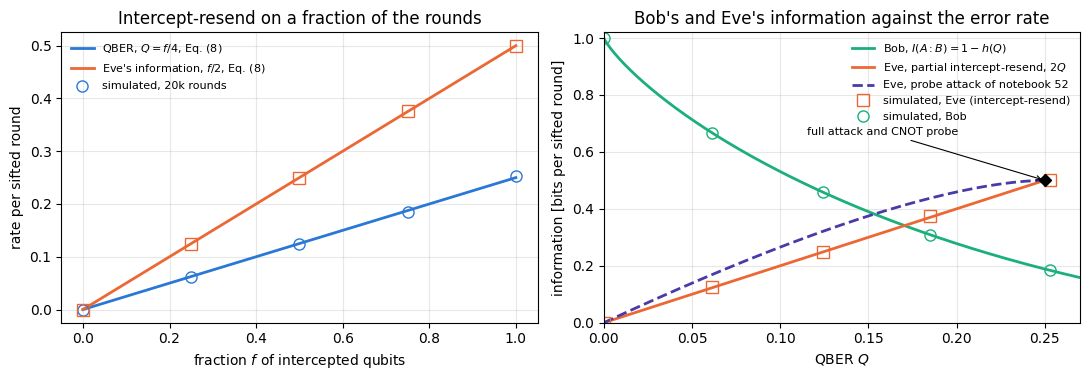

In [11]:
# ==============================================================================
# The CNOT probe of notebook 52 (Eq. (8) there at theta = pi) and the two attack curves
# ==============================================================================
def cnot_probe_attack():
    """QBER and Eve's Helstrom information per sifted round when a CNOT copies the Z bit into a blank probe."""
    Q_list, I_list = [], []
    for basis_states, wrong in (((KET0, KET1), (KET1, KET0)), ((KETP, KETM), (KETM, KETP))):
        out = [apply_gate(jnp.einsum("a,b->ab", s, KET0), CNOT, [0, 1]) for s in basis_states]
        Q_list.append(np.mean([float(jnp.real(jnp.vdot(w, rdm(o, [0]) @ w))) for o, w in zip(out, wrong)]))
        D = float(trace_distance(rdm(out[0], [1]), rdm(out[1], [1])))        # Eve's probes, Helstrom (nb 52, Eq. (3))
        I_list.append(1 - h2((1 - D) / 2))
    return np.mean(Q_list), np.mean(I_list)


Q_cnot, I_cnot = cnot_probe_attack()
print(f"CNOT probe: QBER = {Q_cnot:.4f}, Eve's information = {I_cnot:.4f} bit per sifted round (intercept-resend: "
      f"0.25, 0.5)")
assert abs(Q_cnot - 0.25) < TOL and abs(I_cnot - 0.5) < TOL

theta = np.linspace(0, np.pi, 201)
c = np.cos(theta / 2)
Q_probe = (1 - c) / 4                                                    # notebook 52, Eq. (8)
I_probe = 0.5 * (1 - h2((1 - np.sqrt(1 - c**2)) / 2))
small = (Q_probe > 0) & (Q_probe < 0.003)
print(f"small-Q slope of the probe curve: {np.mean(I_probe[small] / Q_probe[small]):.3f} "
      f"(2/ln 2 = {2 / np.log(2):.3f}); partial intercept-resend: 2")
assert np.all(I_probe[1:] >= 2 * Q_probe[1:] - 1e-12)                   # the probe beats partial intercept-resend
q_cross = np.linspace(1e-4, 0.25, 20001)
Q_eq = q_cross[np.argmin(np.abs(1 - h2(q_cross) - 2 * q_cross))]          # Bob's = Eve's information, Eq. (8)
print(f"partial intercept-resend: Eve knows more than Bob above Q = {Q_eq:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.9))
ff = np.linspace(0, 1, 101)
ax1.plot(ff, ff / 4, color=PALETTE[0], lw=2, label="QBER, $Q=f/4$, Eq. (8)")
ax1.plot(ff, ff / 2, color=PALETTE[1], lw=2, label="Eve's information, $f/2$, Eq. (8)")
ax1.plot(f_values, ir[:, 0], MARKERS[0], color=PALETTE[0], mfc="none", ms=8, label=f"simulated, {N_IR // 1000}k rounds")
ax1.plot(f_values, ir[:, 1], MARKERS[1], color=PALETTE[1], mfc="none", ms=8)
ax1.set_xlabel("fraction $f$ of intercepted qubits"); ax1.set_ylabel("rate per sifted round")
ax1.set_title("Intercept-resend on a fraction of the rounds"); ax1.legend(fontsize=8, loc="upper left")
qq = np.linspace(0, 0.27, 271)
ax2.plot(qq, 1 - h2(qq), color=PALETTE[2], lw=2, label="Bob, $I(A{:}B)=1-h(Q)$")
ax2.plot(qq[qq <= 0.25], 2 * qq[qq <= 0.25], color=PALETTE[1], lw=2, label="Eve, partial intercept-resend, $2Q$")
ax2.plot(Q_probe, I_probe, color=PALETTE[5], lw=2, ls="--", label="Eve, probe attack of notebook 52")
ax2.plot(ir[:, 0], ir[:, 1], MARKERS[1], color=PALETTE[1], mfc="none", ms=8, label="simulated, Eve (intercept-resend)")
ax2.plot(ir[:, 0], ir[:, 2], MARKERS[0], color=PALETTE[2], mfc="none", ms=8, label="simulated, Bob")
ax2.plot([0.25], [0.5], MARKERS[3], color="k", ms=6)
ax2.annotate("full attack and CNOT probe", (0.25, 0.5), xytext=(0.115, 0.66), fontsize=8,
             arrowprops=dict(arrowstyle="->", lw=0.8))
ax2.set_xlabel("QBER $Q$"); ax2.set_ylabel("information [bits per sifted round]")
ax2.set_xlim(0, 0.27); ax2.set_ylim(0, 1.02)
ax2.set_title("Bob's and Eve's information against the error rate"); ax2.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

The engine reproduces the CNOT point exactly: $Q=1/4$ and $1/2$ bit, the same as full intercept–resend.
In the right panel Bob's information falls and Eve's rises with the error rate. For partial intercept–resend the two
cross at $Q\approx17\,\%$, and the probe attack gives Eve more at every error rate below $25\,\%$, with a slope near
zero of $2.9$ instead of $2$. A small error rate therefore still means some leak, and the two attacks shown are only
two of infinitely many. Alice and Bob cannot know which attack Eve used. They need a bound on Eve's knowledge that
holds for every attack compatible with the error rates they observe, and Section 7 derives it.

## 6. Entanglement-based key distribution

### 6.1 BBM92 and the source-replacement picture

Suppose that a source, which could be a third party Charlie or Eve herself, distributes pairs of qubits that should
be in the Bell state $\vert\Phi^+\rangle=(\vert00\rangle+\vert11\rangle)/\sqrt2$ (notebook 19, Section 3). Alice and
Bob each measure their qubit in a randomly chosen basis, $Z$ or $X$, and sift as in BB84. In the $Z$ basis the
outcomes of $\vert\Phi^+\rangle$ are equal; and since $H\otimes H$ leaves $\vert\Phi^+\rangle$ unchanged,

$$\vert\Phi^+\rangle=\tfrac1{\sqrt2}\big(\vert00\rangle+\vert11\rangle\big)=\tfrac1{\sqrt2}\big(\vert{+}{+}\rangle+
\vert{-}{-}\rangle\big), \tag{9}$$

the outcomes are equal in the $X$ basis too. Each outcome by itself is uniformly random. This is the protocol of
Bennett, Brassard and Mermin (1992), called BBM92.

Equation (9) says more. When Alice measures her half in the $Z$ basis and finds $a$, Bob's qubit is left in
$\vert a\rangle$; when she measures in the $X$ basis, Bob's qubit is left in $\vert+\rangle$ or $\vert-\rangle$. In
both cases each outcome has probability $1/2$. Alice's measurement therefore **prepares** exactly the four BB84
states, with a random bit in a basis of her choice, on Bob's side. A BB84 sender is equivalent to a source of
$\vert\Phi^+\rangle$ in Alice's own laboratory, followed by a measurement of her half: from outside the laboratory the
two cannot be told apart. This is the **source-replacement** picture. Bennett, Brassard and Mermin showed this
equivalence, and its use is that security can be analysed for the entanglement-based protocol, where monogamy
(notebook 52, Section 6.2) is directly applicable, and then holds for prepare-and-measure BB84 as well.

The next cell measures Alice's half of $\vert\Phi^+\rangle$ with projectors, computes Bob's conditional state with
`rdm`, and compares it with the BB84 state of Eq. (1). It also checks that Bob's state averaged over Alice's outcomes
is $\mathbb 1/2$ for both of Alice's bases, so that Bob cannot learn the basis from his qubit (no-signalling, notebook
52, Eq. (9)). The wrong control is the classically correlated source $\tfrac12(\vert00\rangle\langle00\vert+
\vert11\rangle\langle11\vert)$, which gives perfect $Z$ correlations as well: an $X$ measurement by Alice leaves
Bob's qubit maximally mixed, so this source cannot replace a BB84 sender.

In [12]:
# ==============================================================================
# Eq. (9): Alice's measurement on |Phi+> prepares the BB84 states on Bob's side
# ==============================================================================
PHI_PLUS = bell_state("phi+")
bb84_state = {(0, 0): KET0, (1, 0): KET1, (0, 1): KETP, (1, 1): KETM}


def alice_projector(a, x):
    """Projector onto Alice's outcome a in basis x: |psi_{a,x}><psi_{a,x}|."""
    v = prepare(a, x)
    return jnp.outer(v, jnp.conj(v))


rho_cl = to_dm(jnp.einsum("a,b->ab", KET0, KET0)) / 2 + to_dm(jnp.einsum("a,b->ab", KET1, KET1)) / 2
print("Alice's basis, outcome | prob. | fidelity of Bob's state with the BB84 state | classical source")
for x in (0, 1):
    rho_B_avg = jnp.zeros((2, 2), dtype=CDTYPE)
    for a in (0, 1):
        phi = apply_gate(PHI_PLUS, alice_projector(a, x), [0])          # unnormalised post-measurement state
        prob = float(jnp.real(jnp.vdot(phi, phi)))
        rho_B = rdm(phi / np.sqrt(prob), [1])                             # Bob's conditional state
        target = bb84_state[(a, x)]
        F = float(jnp.real(jnp.vdot(target, rho_B @ target)))
        rho_B_avg = rho_B_avg + prob * rho_B
        # wrong control: the same measurement on the classically correlated mixture
        r_cl = apply_gate_dm(rho_cl, alice_projector(a, x), [0])
        r_cl_B = dm_matrix(rdm_dm(r_cl, [1]))
        F_cl = float(jnp.real(jnp.vdot(target, r_cl_B @ target) / jnp.trace(r_cl_B)))
        print(f"        {'ZX'[x]}, a = {a}         | {prob:.3f} |{F:28.6f}                   |   {F_cl:.3f}")
        assert abs(prob - 0.5) < TOL and abs(F - 1) < TOL
        assert abs(F_cl - (1.0 if x == 0 else 0.5)) < TOL
    assert float(jnp.max(jnp.abs(rho_B_avg - I2 / 2))) < TOL               # no-signalling: Bob sees 1/2 for both bases

Alice's basis, outcome | prob. | fidelity of Bob's state with the BB84 state | classical source


        Z, a = 0         | 0.500 |                    1.000000                   |   1.000
        Z, a = 1         | 0.500 |                    1.000000                   |   1.000
        X, a = 0         | 0.500 |                    1.000000                   |   0.500
        X, a = 1         | 0.500 |                    1.000000                   |   0.500


Alice's four outcomes leave Bob's qubit in the four BB84 states with fidelity one and probability $1/2$ each, and
Bob's average state is $\mathbb 1/2$ whichever basis Alice chose. The classical source passes the $Z$ test but
fails the $X$ test: after an $X$ measurement by Alice, Bob's qubit has fidelity $1/2$ with the expected state. Perfect
correlations in one basis can come from a classical mechanism, and a copy of such a mechanism could sit with Eve
(the GHZ control of notebook 52, Section 6.2); correlations in two complementary bases cannot.

### 6.2 E91 and the CHSH test

Ekert (1991) proposed the first entanglement-based protocol, in which the pairs are tested with a Bell inequality.
Alice measures $\pm1$-valued observables $A_0$ or $A_1$ and Bob $B_0$ or $B_1$, chosen at random, and from the rounds
with each pair of settings they estimate the CHSH combination of
[notebook 19](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb),

$$S=\langle A_0B_0\rangle+\langle A_0B_1\rangle+\langle A_1B_0\rangle-\langle A_1B_1\rangle . \tag{10}$$

Notebook 19 proves that every local hidden-variable model, any mechanism in which the outcomes are fixed in advance
by shared classical data, obeys $\vert S\vert\leq2$ (Section 5 there), and that quantum mechanics reaches
$2\sqrt2$ (Sections 7–8). With $A_0=Z$, $A_1=X$ and $B_{0,1}=(Z\pm X)/\sqrt2$ the CHSH operator is

$$A_0\otimes(B_0+B_1)+A_1\otimes(B_0-B_1)=\sqrt2\,\big(Z\otimes Z+X\otimes X\big), \tag{11}$$

because $B_0+B_1=\sqrt2Z$ and $B_0-B_1=\sqrt2X$. For $\vert\Phi^+\rangle$, $\langle ZZ\rangle=\langle XX\rangle=1$
and $S=2\sqrt2$. For the Werner pair of visibility $v$,
$\rho_W(v)=v\,\vert\Phi^+\rangle\langle\Phi^+\vert+(1-v)\,\mathbb 1/4$ (notebook 19, Section 11), the noise term has
zero correlators, so $\langle ZZ\rangle=\langle XX\rangle=v$ and $S=2\sqrt2\,v$. The error rate in either basis is
the probability of unequal outcomes, $Q=(1-\langle ZZ\rangle)/2=(1-v)/2$, hence

$$S=2\sqrt2\,v=2\sqrt2\,(1-2Q). \tag{12}$$

A violation of the CHSH inequality, $S>2$, shows that the outcomes were not all fixed in advance, so nobody, Eve
included, could have known all of them before the measurement; Section 8 makes this quantitative. In E91 the key comes
from rounds in which Alice and Bob measure along the same axis (for example a third setting $B_2=Z$ for Bob that
matches $A_0$), and the CHSH rounds serve as the test. The next cell computes $S$ for Werner pairs with the engine,
exactly from the density tensor and by sampling $10^4$ shots per setting, measuring each observable
$\cos\theta\,Z+\sin\theta\,X$ by a rotation $R_y(-\theta)$ followed by a $Z$ measurement, as in notebook 19,
Section 6.3. The wrong control is again the classically correlated source, for which $\langle ZZ\rangle=1$ and
$\langle XX\rangle=0$ give $S=\sqrt2$.

In [13]:
# ==============================================================================
# Eqs. (10)-(12): CHSH for Werner pairs, exact and sampled
# ==============================================================================
CHSH_ANGLES = {"A0": 0.0, "A1": np.pi / 2, "B0": np.pi / 4, "B1": -np.pi / 4}   # A(theta) = cos Z + sin X


def werner(v):
    """Werner pair of visibility v, v |Phi+><Phi+| + (1 - v) 1/4, as a density tensor of shape (2, 2, 2, 2)."""
    return v * to_dm(PHI_PLUS) + (1 - v) * jnp.eye(4, dtype=CDTYPE).reshape(2, 2, 2, 2) / 4


def outcome_probs(rho, theta_a, theta_b):
    """p(s_A, s_B) for the observables A(theta_a), A(theta_b): rotate with R_y(-theta), read the diagonal."""
    r_ = apply_gate_dm(apply_gate_dm(rho, ry(-theta_a), [0]), ry(-theta_b), [1])
    return np.clip(np.real(np.diag(np.asarray(dm_matrix(r_)))), 0, None)          # order 00, 01, 10, 11


SIGNS = np.array([1, -1, -1, 1])                                                 # product of the two +-1 outcomes


def chsh(rho, shots=None, rng=None):
    """Eq. (10) from exact probabilities, or from `shots` sampled outcomes per setting pair."""
    S = 0.0
    for (A, B), sign in zip((("A0", "B0"), ("A0", "B1"), ("A1", "B0"), ("A1", "B1")), (1, 1, 1, -1)):
        p = outcome_probs(rho, CHSH_ANGLES[A], CHSH_ANGLES[B])
        if shots is not None:
            p = rng.multinomial(shots, p / p.sum()) / shots
        S += sign * float(SIGNS @ p)
    return S


rng_chsh = numpy_rng(40)
SHOTS = 10_000
print("   v   | S exact | 2 sqrt2 v | S sampled  | QBER (1-v)/2 | 2 sqrt2 (1-2Q)")
for v in (1.0, 0.9, 0.8, 0.7071, 0.6):
    S_ex, S_mc = chsh(werner(v)), chsh(werner(v), SHOTS, rng_chsh)
    Q_w = float(outcome_probs(werner(v), 0.0, 0.0)[[1, 2]].sum())               # unequal Z outcomes
    print(f" {v:.4f} |  {S_ex:.4f} |  {2 * np.sqrt(2) * v:.4f}   |  {S_mc:.3f}    |    {Q_w:.4f}    |   "
          f"{2 * np.sqrt(2) * (1 - 2 * Q_w):.4f}")
    assert abs(S_ex - 2 * np.sqrt(2) * v) < 1e3 * TOL and abs(Q_w - (1 - v) / 2) < TOL     # Eq. (12)
    assert abs(S_mc - S_ex) < 5 * 2 / np.sqrt(SHOTS)      # 4 independent correlators, each with se <= 1/sqrt(shots)

S_cl = chsh(rho_cl)
print(f"\nwrong control, classically correlated source: S = {S_cl:.4f} (sqrt 2 = {np.sqrt(2):.4f})")
assert abs(S_cl - np.sqrt(2)) < 1e3 * TOL

   v   | S exact | 2 sqrt2 v | S sampled  | QBER (1-v)/2 | 2 sqrt2 (1-2Q)


 1.0000 |  2.8284 |  2.8284   |  2.867    |    0.0000    |   2.8284
 0.9000 |  2.5456 |  2.5456   |  2.532    |    0.0500    |   2.5456
 0.8000 |  2.2627 |  2.2627   |  2.237    |    0.1000    |   2.2627
 0.7071 |  2.0000 |  2.0000   |  1.996    |    0.1465    |   2.0000
 0.6000 |  1.6971 |  1.6971   |  1.692    |    0.2000    |   1.6971

wrong control, classically correlated source: S = 1.4142 (sqrt 2 = 1.4142)


The exact values follow $S=2\sqrt2\,v$, and $10^4$ shots per setting reproduce them within the sampling error. A
Werner pair violates the CHSH inequality for $v>1/\sqrt2\approx0.707$, equivalently for an error rate below
$(1-1/\sqrt2)/2=14.6\,\%$. The classical source stays at $\sqrt2$, far inside the local bound. The CHSH value does
more than detect noise: Section 8 shows that it can bound Eve's knowledge even when nothing is known about the
devices.

## 7. Security from monogamy and the secret-key rate

### 7.1 Bit errors and phase errors

Monogamy gives the qualitative argument. Suppose Alice and Bob find perfect correlations in both bases,
$\langle ZZ\rangle=\langle XX\rangle=1$. The Bell states are the common eigenvectors of $Z\otimes Z$ and
$X\otimes X$, with eigenvalues

$$\begin{aligned}
Z\otimes Z:&\quad+1\ \text{on}\ \vert\Phi^\pm\rangle,\quad-1\ \text{on}\ \vert\Psi^\pm\rangle,\\
X\otimes X:&\quad+1\ \text{on}\ \vert\Phi^+\rangle,\vert\Psi^+\rangle,\quad-1\ \text{on}\
\vert\Phi^-\rangle,\vert\Psi^-\rangle .
\end{aligned} \tag{13}$$

A state with $\langle ZZ\rangle=1$ lives in the span of $\vert\Phi^+\rangle$ and $\vert\Phi^-\rangle$, and
$\langle XX\rangle=1$ then forces it onto $\vert\Phi^+\rangle$, a pure state. By monogamy (notebook 52, Section 6.2) a
pure state of Alice and Bob is uncorrelated with every other system, so Eve knows nothing, and the $Z$ outcomes are
perfectly random and private.

With noise the argument becomes quantitative. It helps to give the two kinds of errors names. If Alice and Bob share
a mixture of Bell states with weights $\lambda_{\Phi^+},\lambda_{\Phi^-},\lambda_{\Psi^+},\lambda_{\Psi^-}$, Eq. (13)
gives

$$Q_Z=\lambda_{\Psi^+}+\lambda_{\Psi^-},\qquad Q_X=\lambda_{\Phi^-}+\lambda_{\Psi^-}. \tag{14}$$

Errors in the $Z$ basis are **bit errors**: they make the $Z$ keys of Alice and Bob differ and must be corrected,
at a cost of $h(Q_Z)$ bits per key bit. Errors in the $X$ basis are **phase errors**: a $\vert\Phi^-\rangle$
component, for example, is $\vert\Phi^+\rangle$ with a $Z$ error on one qubit, which changes no $Z$ outcome. Phase
errors therefore do not touch the $Z$ key at all. What they measure is how far the pair is from the pure state
$\vert\Phi^+\rangle$, and hence how much room is left for Eve to be correlated with the $Z$ key. The CNOT probe of
Section 5.3 shows this at work: it copies the $Z$ bit into Eve's probe and leaves every $Z$ round free of errors, but
Bob's $X$ outcome becomes random, $Q_X=1/2$ (notebook 52, Section 5.2, with $c=0$). Eve's knowledge of the $Z$ key
appears as phase errors. The next cell builds
random Bell-diagonal states, computes both error rates from the engine's outcome probabilities, and checks Eq. (14).

In [14]:
# ==============================================================================
# Eqs. (13)-(14): bit and phase error rates of Bell-diagonal states
# ==============================================================================
BELL = {k: bell_state(k) for k in ("phi+", "phi-", "psi+", "psi-")}
ZZ_op, XX_op = jnp.kron(Z, Z), jnp.kron(X, X)
for k, v in BELL.items():
    vv = v.reshape(-1)
    zz, xx = (float(jnp.real(jnp.vdot(vv, O @ vv))) for O in (ZZ_op, XX_op))
    print(f"|{k}>: <ZZ> = {zz:+.0f}, <XX> = {xx:+.0f}")


def bell_mixture(lam):
    """sum_k lam_k |B_k><B_k| as a density tensor, k in (phi+, phi-, psi+, psi-)."""
    return sum(l * to_dm(BELL[k]) for l, k in zip(lam, BELL))


rng_bd = numpy_rng(41)
worst = 0.0
for _ in range(200):
    lam = rng_bd.dirichlet(np.ones(4))
    rho = bell_mixture(lam)
    QZ = float(outcome_probs(rho, 0.0, 0.0)[[1, 2]].sum())                       # unequal Z outcomes
    QX = float(outcome_probs(rho, np.pi / 2, np.pi / 2)[[1, 2]].sum())           # unequal X outcomes
    worst = max(worst, abs(QZ - (lam[2] + lam[3])), abs(QX - (lam[1] + lam[3])))
print(f"Eq. (14) on 200 random Bell mixtures: largest deviation {worst:.1e}")
assert worst < TOL

|phi+>: <ZZ> = +1, <XX> = +1
|phi->: <ZZ> = +1, <XX> = -1
|psi+>: <ZZ> = -1, <XX> = +1
|psi->: <ZZ> = -1, <XX> = -1


Eq. (14) on 200 random Bell mixtures: largest deviation 3.3e-16


Each Bell state has definite values of $ZZ$ and $XX$, and the error rates of random Bell mixtures follow Eq. (14) to
machine precision. The $\vert\Psi^-\rangle$ component, which flips both $Z$ and $X$ correlations, counts as a bit
error and as a phase error at once.

### 7.2 The Devetak–Winter rate

How many secret bits can Alice and Bob extract per key round, in the limit of many rounds? Consider the
entanglement-based picture, and assume that every round is independent and identical, so that Alice, Bob and Eve
share many copies of one state $\rho_{ABE}$; Section 7.6 comments on this assumption. Alice's key bit is her $Z$
outcome $Z_A$. Devetak and Winter (2005) proved that one-way error correction and privacy amplification, with
messages from Alice to Bob only, achieve the rate

$$r=H(Z_A\vert E)-H(Z_A\vert B). \tag{15}$$

The conditional entropies are those of notebook 50, Section 4, with Eve's or Bob's knowledge in the condition.
The first term is Eve's uncertainty about the key, which privacy amplification turns into secrecy; it is the number of
bits per round that remain hidden from her. The second term is Bob's uncertainty, which error correction must remove
by public messages that Eve hears too; it is the cost of the leak. When Eve holds quantum systems, $H(Z_A\vert E)$ is
the conditional entropy with **quantum side information**: if measuring $Z_A$ leaves the joint state
$\rho_{Z_AE}=\sum_a p_a\,\vert a\rangle\langle a\vert\otimes\rho_E^a$, then

$$H(Z_A\vert E)=S(\rho_{Z_AE})-S(\rho_E), \tag{16}$$

the chain rule of notebook 50, Eq. (9), with von Neumann entropies (notebook 52, Section 6.2). For Bob, who measures
his qubit, $H(Z_A\vert B)$ is at most the classical value $H(Z_A\vert Z_B)$, since processing his system can only
lose information.

Two limits of Eq. (16) show its meaning. If Eve's states $\rho_E^0$ and $\rho_E^1$ are orthogonal, she can read the
bit, and $H(Z_A\vert E)=0$; if they are equal, she has nothing, and $H(Z_A\vert E)=H(Z_A)$. For a uniformly random
key bit, $H(Z_A)=1$, and Eq. (10) of notebook 50 turns Eq. (15) into $r=I(Z_A{:}B)-I(Z_A{:}E)$: a secret key can be
distilled at the rate by which Bob knows more about Alice's bit than Eve does. For intercept–resend the two curves
in the right panel of the figure in Section 5.3 cross at $Q\approx17\,\%$; the threshold derived below is lower,
because it must hold against every attack.

Eve's system is unknown, so $H(Z_A\vert E)$ cannot be measured. Alice and Bob observe only their own outcomes. The
missing link is a relation that bounds Eve's uncertainty by quantities that Alice and Bob can estimate.

### 7.3 The uncertainty relation with quantum memory

Berta, Christandl, Colbeck, Renes and Renner (2010) proved an uncertainty relation that includes quantum memories.
For a qubit of Alice measured either in $Z$ or in $X$, and for any state $\rho_{ABE}$, it reads

$$H(Z_A\vert E)+H(X_A\vert B)\;\geq\;1. \tag{17}$$

In words: Alice's qubit cannot be predicted well in both bases by two different parties. If Bob can predict Alice's
$X$ outcome well, Eve cannot predict her $Z$ outcome well, whatever Eve holds. The bound concerns two different
parties for a reason. A single party with a quantum memory can predict both: Bob, holding the other half of
$\vert\Phi^+\rangle$, predicts $Z_A$ and $X_A$ perfectly, so $H(Z_A\vert B)+H(X_A\vert B)=0$. Entanglement with
Bob is exactly what excludes Eve, and Eq. (17) is the quantitative form of monogamy that security needs.

Bob's prediction of $X_A$ can be tested: in the $X$ rounds his outcome differs from Alice's with probability $Q_X$, so
$H(X_A\vert B)\leq H(X_A\vert X_B)\leq h(Q_X)$. The last step holds because, once Bob's bit is known, Alice's bit is
fixed by the error bit $X_A\oplus X_B$, which is $1$ with probability $Q_X$, and conditioning cannot increase its
entropy $h(Q_X)$ (notebook 50, Section 4). Equation (17) then gives the bound on Eve's uncertainty,

$$H(Z_A\vert E)\;\geq\;1-h(Q_X). \tag{18}$$

The $X$ rounds are not the key rounds, yet they bound Eve's knowledge of the $Z$ key. The reason is that Eve does not
know in which rounds Alice will measure $Z$ and in which $X$, so the key rounds and the $X$ rounds come from the same
state $\rho_{ABE}$. Equation (17) is a property of that state, valid whichever basis Alice then measures, and the $X$ rounds
serve to estimate $Q_X$ for it.

The next cell implements Eq. (16) for pure states of four qubits, $A$, $B$ and a two-qubit Eve, which suffices to
purify any state of Alice and Bob. The conditional entropy is computed from the reduced density matrix of Alice's
qubit and the memory, after a rotation to the measured basis, by deleting the off-diagonal blocks in Alice's index,
which is the effect of the measurement. On $400$ Haar-random states it checks Eq. (17) and the step
$H(X_A\vert B)\leq h(Q_X)$, and the wrong control evaluates the single-party sum for $\vert\Phi^+\rangle$.

In [15]:
# ==============================================================================
# Eqs. (16)-(18): conditional entropies with quantum memory and the uncertainty relation
# ==============================================================================
@partial(jax.jit, static_argnums=(1, 2))
def _cond_entropy(omega, basis, memory):
    """Eq. (16): H(K_A | M) for Alice's outcome K_A in `basis` ('Z' or 'X') and memory qubits `memory`, from a pure
    state omega of shape (2,)*n with Alice = qubit 0.
    IMPLEMENTATION  rotate qubit 0 so that the measured basis becomes Z; rho_{A M} = rdm; the measurement keeps
    only the two diagonal blocks in Alice's index (A is the most significant index of the matrix)."""
    psi = apply_gate(omega, H, [0]) if basis == "X" else omega
    r_am = rdm(psi, [0, *memory])
    d = r_am.shape[0] // 2
    mask = jnp.kron(jnp.eye(2), jnp.ones((d, d)))                            # keeps the blocks |a><a| (x) rho_M^a
    return von_neumann_entropy(r_am * mask) - von_neumann_entropy(rdm(psi, list(memory)))


def cond_entropy(omega, basis, memory):
    return float(_cond_entropy(jnp.asarray(omega, dtype=CDTYPE), basis, tuple(memory))) + 0.0


def error_rate(omega, basis):
    """Probability that Alice and Bob (qubits 0, 1) find unequal outcomes in the same basis."""
    psi = apply_gate(apply_gate(omega, H, [0]), H, [1]) if basis == "X" else omega
    r_ab = np.real(np.diag(np.asarray(rdm(psi, [0, 1]))))
    return float(r_ab[1] + r_ab[2])


EVE, BOB = (2, 3), (1,)
sums, gaps = [], []
for j in range(400):
    omega = haar_state(key_for(1000 + j), 4)                                # qubits A, B, E1, E2
    sums.append(cond_entropy(omega, "Z", EVE) + cond_entropy(omega, "X", BOB))
    gaps.append(h2(error_rate(omega, "X")) - cond_entropy(omega, "X", BOB))
print(f"400 random states: min of H(Z_A|E) + H(X_A|B) = {min(sums):.4f}  (Eq. (17): >= 1)")
print(f"                   min of h(Q_X) - H(X_A|B)   = {min(gaps):.4f}  (must be >= 0)")
assert min(sums) >= 1 - 1e-9 and min(gaps) >= -1e-9

# wrong control: one party with a quantum memory predicts both outcomes
omega_bell = jnp.einsum("ab,cd->abcd", PHI_PLUS, product_state("00"))
single = cond_entropy(omega_bell, "Z", BOB) + cond_entropy(omega_bell, "X", BOB)
print(f"wrong control, |Phi+>: H(Z_A|B) + H(X_A|B) = {single:.2e}; with Eve: "
      f"H(Z_A|E) + H(X_A|B) = {cond_entropy(omega_bell, 'Z', EVE) + cond_entropy(omega_bell, 'X', BOB):.4f}")
assert abs(single) < 1e-9

400 random states: min of H(Z_A|E) + H(X_A|B) = 1.0149  (Eq. (17): >= 1)
                   min of h(Q_X) - H(X_A|B)   = 0.0023  (must be >= 0)
wrong control, |Phi+>: H(Z_A|B) + H(X_A|B) = 2.13e-14; with Eve: H(Z_A|E) + H(X_A|B) = 1.0000


No random state comes below one in Eq. (17), and Bob's quantum uncertainty about $X_A$ never exceeds $h(Q_X)$. For the
Bell pair, Bob predicts both outcomes perfectly, and the sum over a single party is zero, while Eve, who holds a
product state, has one full bit of uncertainty.

### 7.4 The BB84 key rate

Inserting Eq. (18) and $H(Z_A\vert B)\leq h(Q_Z)$ into Eq. (15) gives the secret-key rate per key round,

$$r\;\geq\;1-h(Q_X)-h(Q_Z)\;\xrightarrow{\;Q_X=Q_Z=Q\;}\;1-2h(Q). \tag{19}$$

The first $h$ is the price of Eve's possible knowledge, paid in privacy amplification, and the second is the price of
error correction. This chain of inequalities is the argument of Berta and coauthors (2010), and it recovers the rate
that Shor and Preskill (2000) proved for BB84 with a different argument based on quantum error-correcting codes. It
vanishes when $h(Q)=1/2$, at

$$Q^\ast=11.0\,\% . \tag{20}$$

Below this error rate Alice and Bob can extract a secret key; above it this protocol, with one-way error correction
and privacy amplification, gives none, and they abort. Intercept–resend, at $Q=25\,\%$, is far above the threshold.
Under the assumption of independent rounds stated in Section 7.2, Eq. (19) holds for every state that Eve may have
prepared, which Alice and Bob need since they never learn which attack she used. The bound is also tight: some state
that Eve can prepare reaches it. The next cell purifies Bell-diagonal states with $Q_X=Q_Z=Q$, giving Eve the
purifying system (the worst case of notebook 52, Section 6.2), $\vert\Omega\rangle=\sum_k\sqrt{\lambda_k}\,\vert B_k\rangle_{AB}\vert k\rangle_E$, and scans the
one free weight $\lambda_{\Psi^-}=t$ (by Eq. (14), $\lambda_{\Psi^+}=\lambda_{\Phi^-}=Q-t$). The smallest
$H(Z_A\vert E)$ equals $1-h(Q)$ and is reached at $t=Q^2$, the state produced by independent bit and phase flips
with probability $Q$ each, with weights $\big((1-Q)^2,Q(1-Q),Q(1-Q),Q^2\big)$. The Werner pair with the same error
rate, $t=Q/2$, gives Eve less. A bisection then locates the threshold of Eq. (20).

In [16]:
# ==============================================================================
# Eqs. (19)-(20): Eve's uncertainty for purified Bell mixtures, the key rate and its threshold
# ==============================================================================
def purified_bell_mixture(lam):
    """|Omega> = sum_k sqrt(lam_k) |B_k>_AB |k>_E with Eve's two qubits E1 E2 (qubits A, B, E1, E2)."""
    eve = [product_state(s) for s in ("00", "01", "10", "11")]
    return sum(np.sqrt(l) * jnp.einsum("ab,cd->abcd", BELL[k], e) for l, k, e in zip(lam, BELL, eve))


print("   Q   | min_t H(Z_A|E) | at t  (Q^2)       | 1 - h(Q) | Werner (t = Q/2) | r = 1 - 2h(Q)")
for Q in (0.02, 0.05, 0.08, 0.11):
    ts = np.sort(np.append(np.linspace(0, Q, 81), Q * Q))                  # the grid plus the point t = Q^2
    HZE = np.array([cond_entropy(purified_bell_mixture([1 - 2 * Q + t, Q - t, Q - t, t]), "Z", EVE) for t in ts])
    H_werner = cond_entropy(purified_bell_mixture([1 - 1.5 * Q, Q / 2, Q / 2, Q / 2]), "Z", EVE)
    i = HZE.argmin()
    print(f" {Q:.2f}  |     {HZE[i]:.6f}   | {ts[i]:.6f} ({Q * Q:.6f}) | {1 - h2(Q):.6f} |     {H_werner:.6f}     | "
          f"{1 - 2 * h2(Q):+.4f}")
    assert np.all(HZE >= 1 - h2(Q) - 1e-9)                                  # Eq. (18) on the whole scan
    assert abs(HZE.min() - (1 - h2(Q))) < 1e-9 and abs(ts[i] - Q * Q) < 1e-12   # reached at t = Q^2
    assert H_werner > 1 - h2(Q) + 1e-3

lo, hi = 0.05, 0.2                                                           # bisection for 1 - 2h(Q) = 0
for _ in range(60):
    mid = 0.5 * (lo + hi)
    lo, hi = (mid, hi) if 1 - 2 * h2(mid) > 0 else (lo, mid)
Q_STAR = lo
print(f"\nthreshold of Eq. (20): Q* = {Q_STAR:.5f}")
assert abs(Q_STAR - 0.110028) < 1e-5

   Q   | min_t H(Z_A|E) | at t  (Q^2)       | 1 - h(Q) | Werner (t = Q/2) | r = 1 - 2h(Q)


 0.02  |     0.858559   | 0.000400 (0.000400) | 0.858559 |     0.899500     | +0.7171


 0.05  |     0.713603   | 0.002500 (0.002500) | 0.713603 |     0.783213     | +0.4272


 0.08  |     0.597821   | 0.006400 (0.006400) | 0.597821 |     0.682623     | +0.1956


 0.11  |     0.500084   | 0.012100 (0.012100) | 0.500084 |     0.592259     | +0.0002

threshold of Eq. (20): Q* = 0.11003


For every error rate in the table the smallest value of Eve's uncertainty over the scan is exactly $1-h(Q)$, at
$t=Q^2$, so the uncertainty bound of Eq. (18) is reached by an attack that produces independent bit and phase flips.
Werner pairs with the same error rate leave Eve less: their weight $Q/2$ on $\vert\Psi^-\rangle$, which carries a
bit error and a phase error together, is larger than $Q^2$, and correlated errors leave less room for Eve. Alice and
Bob, who measure only in $Z$ and $X$, cannot tell the two states apart and must assume the worst case. The rate
$1-2h(Q)$ falls from $0.72$ at $2\,\%$ to $0.43$ at $5\,\%$ and crosses zero at $Q^\ast=11.0\,\%$.

### 7.5 Werner pairs as the source

If the source emits Werner pairs $\rho_W(v)$, Eq. (12) gives $Q_Z=Q_X=(1-v)/2$, and their fidelity with
$\vert\Phi^+\rangle$ is $F=v+(1-v)/4=(1+3v)/4$. The key threshold $Q^\ast$ translates into

$$v^\ast=1-2Q^\ast\approx0.78,\qquad F^\ast=\tfrac{1+3v^\ast}{4}\approx0.835 . \tag{21}$$

Werner pairs are entangled for $v>1/3$ (notebook 19, Section 11) and violate the CHSH inequality for $v>1/\sqrt2$.
Pairs with $1/3<v<0.78$ are entangled but give no key with the post-processing used here. Other post-processing
tolerates more noise: if Alice flips each of her key bits at random before error correction, one-way
communication still gives a key up to $Q=12.4\,\%$ (Kraus, Gisin and Renner 2005), and the two-way protocol of
Gottesman and Lo (2003) tolerates $18.9\,\%$. The last part of this chapter returns to noisy pairs and
to how they can be purified before use.

In [17]:
# ==============================================================================
# Eq. (21): the thresholds of Werner pairs
# ==============================================================================
v_star = 1 - 2 * Q_STAR
F_star = (1 + 3 * v_star) / 4
F_engine = float(jnp.real(jnp.vdot(PHI_PLUS.reshape(-1), dm_matrix(werner(v_star)) @ PHI_PLUS.reshape(-1))))
print(f"key threshold v* = {v_star:.4f}, fidelity F* = {F_star:.4f} (engine: {F_engine:.4f})")
print(f"CHSH violation for v > {1 / np.sqrt(2):.4f} (Q < {(1 - 1 / np.sqrt(2)) / 2:.4f}); entangled for v > 1/3 "
      f"(Q < {1 / 3:.4f})")
assert abs(v_star - 0.77994) < 1e-4 and abs(F_engine - F_star) < TOL
assert 1 / 3 < 1 / np.sqrt(2) < v_star                                       # entangled < CHSH < key

key threshold v* = 0.7799, fidelity F* = 0.8350 (engine: 0.8350)
CHSH violation for v > 0.7071 (Q < 0.1464); entangled for v > 1/3 (Q < 0.3333)


The three thresholds are ordered: a Werner pair must be entangled ($v>1/3$) to be useful at all, it violates CHSH
from $v=0.707$ on, and it gives a BB84 key from $v=0.780$ on, with fidelity $0.835$.

### 7.6 Efficient BB84 and the classes of attacks

With equal basis probabilities, half of the rounds are lost in sifting. Lo, Chau and Ardehali (2005) showed that the
bases may be chosen with very different probabilities, $Z$ almost always and $X$ only rarely, if the error rate is
estimated separately for each basis; the fraction of sifted rounds then approaches one.

Security proofs distinguish three classes of attacks. In **individual attacks** Eve treats every qubit separately
with a fresh probe and measures each probe separately; intercept–resend and the probe attack of notebook 52 measured
one probe at a time are examples. In **collective attacks** she still attacks every qubit separately and in the same
way, but stores all her probes in a quantum memory and measures them jointly at the end, after hearing all public
messages. In **coherent attacks** she does the most general thing quantum mechanics allows, entangling all qubits with
one large probe. The rate of Eq. (19) was derived above for collective attacks, where the rounds are independent and
identical; for BB84 it holds against coherent attacks as well, as Shor and Preskill (2000) proved with an argument
based on quantum error-correcting codes. A route that works for many protocols uses symmetry: Alice and Bob may
permute their rounds at random, and a state that is symmetric under permutations of many subsystems is close to a
mixture of independent and identical ones (Renner 2007), so the general case reduces to the independent one at the
price of finite-size corrections. A key that passes the full analysis is secure in a strong sense: it may be used
in any later
protocol, such as the one-time pad, as if it were a perfectly random key unknown to Eve, up to a failure probability
that Alice and Bob choose, for example $10^{-10}$.

### 7.7 The simulated protocol against the asymptotic rate

The pipeline of Section 4 can now be compared with Eq. (19). The next cell runs it at error rates from $1$ to
$10\,\%$, each time with $4\times10^4$ rounds through a depolarising channel with $p_{\rm dep}=3Q/2$ (Eq. (3)), and
records the extracted key length per reconciled bit, $\ell/n$ from Eq. (5). The extracted fraction is

$$\frac\ell n=1-h(\hat Q)-\frac{\text{leak}}n-\frac sn\approx1-(1+f)\,h(\hat Q)-\frac sn,$$

with the reconciliation efficiency $f_{\rm EC}$ of Section 4.5, so it lies below $1-2h(Q)$ by $(f_{\rm EC}-1)h(\hat Q)+s/n$, the cost of an error correction that is not optimal and of the
safety margin. When Eq. (5) gives $\ell\leq0$, the protocol aborts.

In [18]:
# ==============================================================================
# The full protocol at several error rates (Eqs. (3)-(5)) against Eq. (19)
# ==============================================================================
def run_protocol(i, Q_target, n_sent=N_SENT):
    """BB84 end to end through a depolarising channel with Q = Q_target. Returns a dict of results."""
    rounds = simulate_rounds(key_for(200 + i), n_sent, p_dep=1.5 * Q_target)              # Eq. (3)
    rng = numpy_rng(300 + i)
    a_k, b_k, est = sift_and_estimate(rounds, rng)
    b_c, leak, verified = correct_errors(a_k, b_k, est["Q"], rng)
    n = a_k.size
    ell = n - leak - int(np.ceil(n * h2(est["Q"]))) - S_MARGIN                         # Eq. (5)
    res = dict(est, n=n, leak=leak, ell=ell, verified=verified, f_ec=(leak - N_VERIFY) / max(n * h2(est["Q"]), 1))
    if ell > 0:
        seed = int(rng.integers(2**31))
        res["equal"] = np.array_equal(random_hash(a_k, ell, seed), random_hash(b_c, ell, seed))
    return res


Q_TARGETS = (0.01, 0.02, 0.04, 0.06, 0.08, 0.10)
runs = [run_protocol(i, Q) for i, Q in enumerate(Q_TARGETS)]
print(" Q chan | Q_hat +- sigma   | leak/n | f    | l/n    | 1 - 2h(Q_hat) | result")
for Q, res in zip(Q_TARGETS, runs):
    frac = res["ell"] / res["n"]
    outcome = f"key of {res['ell']} bits, identical: {res['equal']}" if res["ell"] > 0 else "abort (l <= 0)"
    print(f"  {Q:.2f}  | {res['Q']:.4f} +- {res['sigma']:.4f} | {res['leak'] / res['n']:.4f} | {res['f_ec']:.2f} | "
          f"{frac:+.4f} |    {1 - 2 * h2(res['Q']):+.4f}    | {outcome}")
    assert res["verified"] and abs(res["Q"] - Q) < 5 * binom_se(Q, res["k"])
    assert frac < 1 - 2 * h2(res["Q"])                                       # below the asymptotic rate
    expected_gap = (res["leak"] - res["n"] * h2(res["Q"]) + S_MARGIN) / res["n"]
    assert abs((1 - 2 * h2(res["Q"]) - frac) - expected_gap) < 2 / res["n"]  # the gap is the excess leak + margin
    if res["ell"] > 0:
        assert res["equal"]
assert runs[0]["ell"] > 0 and runs[-1]["ell"] <= 0                           # key at 1 %, abort at 10 %

 Q chan | Q_hat +- sigma   | leak/n | f    | l/n    | 1 - 2h(Q_hat) | result
  0.01  | 0.0094 +- 0.0022 | 0.0926 | 1.16 | +0.8276 |    +0.8459    | key of 14995 bits, identical: True
  0.02  | 0.0201 +- 0.0031 | 0.1733 | 1.20 | +0.6822 |    +0.7166    | key of 12247 bits, identical: True
  0.04  | 0.0425 +- 0.0045 | 0.3190 | 1.24 | +0.4245 |    +0.4925    | key of 7637 bits, identical: True
  0.06  | 0.0566 +- 0.0051 | 0.4357 | 1.38 | +0.2477 |    +0.3724    | key of 4491 bits, identical: True
  0.08  | 0.0850 +- 0.0062 | 0.5363 | 1.27 | +0.0413 |    +0.1609    | key of 744 bits, identical: True
  0.10  | 0.0931 +- 0.0065 | 0.6230 | 1.39 | -0.0725 |    +0.1065    | abort (l <= 0)


At every error rate the keys of Alice and Bob came out identical, and the extracted fraction lies below $1-2h(Q)$ by
the excess leak of the parity-check reconciliation plus the margin. At $1\,\%$ the protocol keeps $98\,\%$ of the
asymptotic rate, at $6\,\%$ two thirds of it and at $8\,\%$ only a quarter, because the excess leak $(f-1)h(Q)$
grows with $h(Q)$ while the rate shrinks. In the last run, with an estimated error rate of $9.3\,\%$ and an
asymptotic rate of $0.11$, the leak of $1.39\,h(\hat Q)$ makes Eq. (5) negative, and the protocol aborts although the
error rate is below the threshold $Q^\ast$. Real systems use long low-density parity-check codes with $f$ close to
one (notebook 50, Section 5.3) to come closer to Eq. (19).

### 7.8 A finite number of rounds

Equation (19) is an asymptotic statement. With a finite number of rounds three corrections appear. The error rate is
estimated from $k$ test rounds and is uncertain by about $\sigma_{\hat Q}$ of Eq. (4), so a careful protocol inserts a
pessimistic value $\hat Q+\mu$, with $\mu$ a few standard errors, into the term for Eve's knowledge; error correction
on finite blocks leaks more than $n\,h(Q)$, as in Section 7.7; and privacy amplification needs a margin $s$ that grows
with the required security level. For small numbers of rounds these corrections exceed the rate itself, and no key
can be extracted at all. Tight finite-key analyses of BB84 are given by Tomamichel, Lim, Gisin and Renner (2012). The
next cell shows the first correction with the engine: one simulation of $8\times10^5$ rounds at $Q=5\,\%$ is cut
into many independent test samples of size $k$, and the spread of $\hat Q$ is compared with Eq. (4); the last column
shows the rate $1-2h$ evaluated at $\hat Q+3\sigma_{\hat Q}$ instead of $Q$.

In [19]:
# ==============================================================================
# Eq. (4): spread of the estimated error rate, and its cost in the key rate
# ==============================================================================
Q_FS = 0.05
r_fs = simulate_rounds(key_for(400), 800_000, p_dep=1.5 * Q_FS)
s_fs = r_fs["x"] == r_fs["y"]
err_fs = (r_fs["a"][s_fs] != r_fs["b"][s_fs]).astype(float)
print(f"{err_fs.size} sifted rounds, overall error rate {err_fs.mean():.4f}")
print("    k   | samples | std of Q_hat | Eq. (4) | 1 - 2h(Q + 3 sigma)  (asymptotic 1 - 2h(Q) = "
      f"{1 - 2 * h2(Q_FS):.4f})")
for k in (100, 1_000, 10_000):
    m = err_fs.size // k
    Q_hats = err_fs[: m * k].reshape(m, k).mean(1)                          # m independent test samples of size k
    sig = np.sqrt(Q_FS * (1 - Q_FS) / k)
    std = Q_hats.std(ddof=1)
    print(f" {k:6d} | {m:7d} |    {std:.4f}    | {sig:.4f}  |      {1 - 2 * h2(Q_FS + 3 * sig):+.4f}")
    assert abs(std - sig) < 5 * sig / np.sqrt(2 * (m - 1))                  # standard error of a standard deviation

399767 sifted rounds, overall error rate 0.0506
    k   | samples | std of Q_hat | Eq. (4) | 1 - 2h(Q + 3 sigma)  (asymptotic 1 - 2h(Q) = 0.4272)
    100 |    3997 |    0.0219    | 0.0218  |      -0.0319
   1000 |     399 |    0.0070    | 0.0069  |      +0.2631
  10000 |      39 |    0.0024    | 0.0022  |      +0.3729


The spread of the estimate follows $\sqrt{Q(1-Q)/k}$: $2.2\,\%$ for $100$ test rounds, $0.7\,\%$ for $1000$ and
$0.2\,\%$ for $10^4$. With a margin of three standard errors, $100$ test rounds at $Q=5\,\%$ already push the
pessimistic error rate above the threshold, so no key at all; $10^3$ test rounds cost $40\,\%$ of the rate and
$10^4$ test rounds about an eighth. The end-to-end runs of Sections 4 and 7.7 used $\hat Q$ itself in Eq. (5),
without this margin, and therefore illustrate the protocol without the statistical guarantee that a deployed
system needs.

## 8. Device-independent key distribution

Every argument above assumes that Alice's and Bob's devices measure exactly $Z$ and $X$ on qubits. Real devices
deviate from their models, and Section 9 shows that such deviations have been exploited. **Device-independent** key
distribution drops this assumption. The devices are black boxes with a setting as input and a bit as output, and
security is derived from the observed CHSH value $S$ of Eq. (10) alone. A value above $2$ certifies that the outcomes
were not fixed in advance, and a value near $2\sqrt2$ certifies a nearly maximally entangled pair, whatever the
devices do inside. For collective attacks Acín, Brunner, Gisin, Massar, Pironio and Scarani (2007) derived the bound
on Eve's information as a function of $S$, which gives the rate

$$r_{\rm DI}\;\geq\;1-h(Q)-h\!\left(\frac{1+\sqrt{(S/2)^2-1}}{2}\right). \tag{22}$$

The structure is that of Eq. (19): $h(Q)$ is the cost of error correction on the key rounds, and the second entropy
replaces $h(Q_X)$ as the bound on Eve's knowledge. For $S=2\sqrt2$ the square root is one and the second term
vanishes; for $S=2$ it is $h(1/2)=1$ and no key is possible. For Werner pairs, $S=2\sqrt2(1-2Q)$ by Eq. (12), and the
rate vanishes at $Q\approx7.1\,\%$, lower than the $11\,\%$ of BB84: fewer assumptions cost noise tolerance.
Security against general attacks was proved by Vazirani and Vidick (2014). Device-independent protocols need Bell
tests without loopholes over long distances, which makes them much harder to run than BB84.

An intermediate option is **measurement-device-independent** key distribution (Lo, Curty and Qi 2012): Alice and Bob
send states to an untrusted relay in the middle, which performs Bell measurements, so that every attack on the
detectors is removed while the sources must still be trusted.

The next cell evaluates Eq. (22) for Werner pairs, with $S$ and $Q$ computed by the engine, locates the threshold,
and draws both rates together with the key fractions extracted by the simulated protocol of Section 7.7.

device-independent threshold: Q = 0.0715; BB84 threshold: Q* = 0.1100
at Q = 2 %: BB84 rate 0.7171, device-independent rate 0.6123


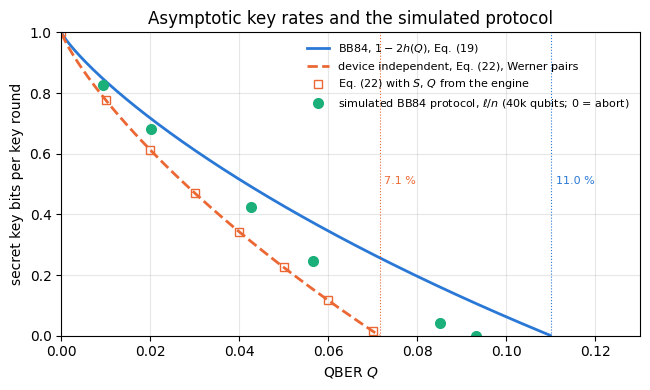

In [20]:
# ==============================================================================
# Eq. (22): the device-independent rate for Werner pairs, and the key-rate figure
# ==============================================================================
def r_di(S, Q):
    """Eq. (22); S <= 2 gives no key."""
    if S <= 2:
        return -1.0
    return 1 - h2(Q) - h2((1 + np.sqrt((S / 2) ** 2 - 1)) / 2)


Qg = np.linspace(0.0, 0.13, 131)
rate_di_engine = []
for Q in Qg[::10]:
    rho = werner(1 - 2 * Q)
    S_w, Q_w = chsh(rho), float(outcome_probs(rho, 0.0, 0.0)[[1, 2]].sum())
    rate_di_engine.append(r_di(S_w, Q_w))
    assert abs(rate_di_engine[-1] - r_di(2 * np.sqrt(2) * (1 - 2 * Q), Q)) < 1e-9     # Eq. (12) inside Eq. (22)
lo, hi = 0.01, 0.1
for _ in range(60):
    mid = 0.5 * (lo + hi)
    lo, hi = (mid, hi) if r_di(2 * np.sqrt(2) * (1 - 2 * mid), mid) > 0 else (lo, mid)
Q_STAR_DI = lo
print(f"device-independent threshold: Q = {Q_STAR_DI:.4f}; BB84 threshold: Q* = {Q_STAR:.4f}")
print(f"at Q = 2 %: BB84 rate {1 - 2 * h2(0.02):.4f}, device-independent rate "
      f"{r_di(2 * np.sqrt(2) * 0.96, 0.02):.4f}")
assert abs(Q_STAR_DI - 0.0715) < 5e-4 and r_di(2.0, 0.0) < 0

fig, ax = plt.subplots(figsize=(6.6, 4.0))
qf = np.linspace(1e-4, 0.13, 600)
bb84_curve = 1 - 2 * h2(qf)
di_curve = np.array([r_di(2 * np.sqrt(2) * (1 - 2 * q), q) for q in qf])
ax.plot(qf[bb84_curve > 0], bb84_curve[bb84_curve > 0], color=PALETTE[0], lw=2, label="BB84, $1-2h(Q)$, Eq. (19)")
ax.plot(qf[di_curve > 0], di_curve[di_curve > 0], color=PALETTE[1], lw=2, ls="--",
        label="device independent, Eq. (22), Werner pairs")
ax.plot(Qg[::10][np.array(rate_di_engine) > 0], np.array(rate_di_engine)[np.array(rate_di_engine) > 0],
        MARKERS[1], color=PALETTE[1], mfc="none", ms=6, label="Eq. (22) with $S$, $Q$ from the engine")
sim_Q = [res["Q"] for res in runs]
sim_frac = [max(res["ell"] / res["n"], 0.0) for res in runs]
ax.plot(sim_Q, sim_frac, MARKERS[0], color=PALETTE[2], ms=7,
        label=f"simulated BB84 protocol, $\\ell/n$ ({N_SENT // 1000}k qubits; 0 = abort)")
ax.axvline(Q_STAR, color=PALETTE[0], lw=0.8, ls=":"); ax.axvline(Q_STAR_DI, color=PALETTE[1], lw=0.8, ls=":")
ax.text(Q_STAR + 0.001, 0.5, "11.0 %", color=PALETTE[0], fontsize=8)
ax.text(Q_STAR_DI + 0.001, 0.5, "7.1 %", color=PALETTE[1], fontsize=8)
ax.set_xlim(0, 0.13); ax.set_ylim(0, 1.0)
ax.set_xlabel("QBER $Q$"); ax.set_ylabel("secret key bits per key round")
ax.set_title("Asymptotic key rates and the simulated protocol"); ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

The device-independent rate, with $S$ and $Q$ taken from the engine's Werner pairs, lies below the BB84 rate at every
error rate and vanishes at $7.1\,\%$, against $11.0\,\%$ for BB84. The simulated BB84 points lie under their curve,
by the excess leak of the reconciliation, and the last point sits at zero, where the protocol aborted. The vertical
lines mark the two thresholds.

## 9. Practical issues

**Loss.** Most photons sent into a long fibre never arrive. With a source of single photons, lost photons do not open
a door for Eve, since Alice and Bob simply discard the rounds without a detection, but they do not contribute to the
key either. The key rate is
therefore proportional to the transmission $\eta$ of the link, and since a fibre attenuates the signal by a fixed
number of decibels per kilometre, $\eta$ and the rate fall exponentially with distance. No-cloning forbids amplifying
the quantum signal (notebook 52, Section 4); long distances need trusted relay stations or quantum repeaters, which
are built from entanglement swapping and purification and are the subject of the next notebook of this chapter.

**Multi-photon pulses and decoy states.** Practical sources are attenuated lasers. Each pulse contains a random
number of photons, and occasionally two or more. Eve can then keep one photon and forward the others, and once the
basis is announced she measures her photon in the right basis, learning the bit without causing any error. On a
lossy line she can also block single-photon pulses, so that Bob's detection rate stays at its expected value. This is
the **photon-number-splitting** attack. The **decoy-state** method defeats it (Hwang 2003; Lo, Ma and Chen 2005; Wang
2005). Alice varies the intensity of her pulses at random and reveals the intensities only afterwards. Eve cannot
treat pulses differently without knowing their intensity, and from the detection rates at each intensity Alice and
Bob estimate how many detections came from single-photon pulses; only those enter the key-rate formula.

**Imperfect detectors.** Detectors and modulators deviate from their models, and each deviation is a potential side
channel. Lydersen and coauthors (2010) blinded the single-photon detectors of two commercial systems with bright light
and controlled their clicks remotely, which makes it possible to acquire the full key without leaving a trace. The
answer is either to model and patch every such side channel, or to remove the assumptions that the attack exploits:
the measurement-device-independent protocol removes all detector attacks, and device-independent protocols remove the
assumptions on the devices altogether. The review by Scarani and coauthors (2009) treats the security of practical
systems in detail.

## 10. Key takeaways

* **BB84 encodes bits in two bases and reveals the basis only after the measurement.** A measurement in the right
  basis returns Alice's bit, one in the wrong basis a coin toss, Eq. (2); sifting keeps the half of the rounds with
  equal bases. The simulated protocol turned $4\times10^4$ qubits at $Q=3\,\%$ into a key of about $10^4$ bits that
  Alice and Bob share bit for bit.
* **The classical stage is the toolbox of notebooks 50 and 51.** The error rate is estimated on a random sample,
  with a standard error $\sqrt{Q(1-Q)/k}$; parity checks correct the errors at a cost of $f_{\rm EC}\,h(Q)$ bits per key bit;
  a random hash removes Eve's knowledge, Eq. (5). Hashing before correcting leaves keys that differ in half of their
  bits.
* **Intercept–resend causes a $25\,\%$ error rate** and gives Eve half a bit per sifted round, Eqs. (6)–(8); the CNOT
  probe of notebook 52 gives the same numbers, and weaker probes give more information per error.
* **A BB84 sender is a source of $\vert\Phi^+\rangle$ with a measurement in Alice's laboratory.** This source
  replacement links BB84 with the entanglement-based protocols BBM92 and E91; Werner pairs of visibility $v$ have
  $S=2\sqrt2\,v$ and $Q=(1-v)/2$.
* **Phase errors bound Eve's knowledge.** The Devetak–Winter rate $H(Z_A\vert E)-H(Z_A\vert B)$, together with the
  uncertainty relation $H(Z_A\vert E)+H(X_A\vert B)\geq1$, gives the BB84 rate $1-h(Q_X)-h(Q_Z)=1-2h(Q)$, positive
  below $Q^\ast=11.0\,\%$ ($v^\ast=0.78$ for Werner pairs). Independent bit and phase flips reach the bound.
* **Real keys are shorter.** Error correction above the Shannon limit, the safety margin and the statistical
  uncertainty of $\hat Q$ all cost key; the simulated protocol aborted at $10\,\%$.
* **Device independence trades noise tolerance for fewer assumptions.** The CHSH-based rate vanishes at $7.1\,\%$.
  Real devices have been attacked through multi-photon pulses (answered by decoy states) and through their detectors
  (answered by measurement-device-independent protocols).

## 11. Exercises

1. ★ **Partial intercept–resend.** Eve attacks a fraction $f$ of the rounds. What is the largest $f$ that keeps the
   error rate below $Q^\ast$? How much does Eve learn per sifted round at that $f$, and why does this not endanger the
   key? Check the error rate with `simulate_rounds`.
2. ★ **A key at 5 %.** Compute the asymptotic rate per key round at $Q=5\,\%$. How many secret bits does one obtain
   from $10^6$ sent qubits with equal basis probabilities, and how many if both Alice and Bob choose $Z$ with
   probability $0.9$ and the key is taken from the rounds in which both chose $Z$? Ignore the test rounds and loss.
3. ★★ **CHSH and the error rate.** Show with Eq. (11) that $S=2\sqrt2\,v$ for $\rho_W(v)$. For which $v$ is the
   inequality violated, and which error rate does that correspond to? Confirm with `chsh(werner(v))`.
4. ★★ **The only state with perfect correlations.** Show that $\vert\Phi^+\rangle$ is the only two-qubit state, pure
   or mixed, with $\langle ZZ\rangle=\langle XX\rangle=1$. Then draw $10^4$ random density matrices of rank two
   (mixtures of two Haar-random states) and check numerically that
   $\langle ZZ\rangle+\langle XX\rangle\leq2F_{\Phi^+}$, with $F_{\Phi^+}$ the fidelity with $\vert\Phi^+\rangle$, so
   that a sum close to $2$ forces a fidelity close to one.
5. ★★ **Intercept–resend in the intermediate basis.** Eve measures every qubit along the Bloch direction halfway
   between $+z$ and $+x$ (the observable $(Z+X)/\sqrt2$) and resends the eigenstate she found. Extend `one_round`:
   rotate with `ry(-np.pi / 4)`, measure $Z$, rotate back with `ry(np.pi / 4)`, as in notebook 19, Section 6.3.
   Compute the error rate, the probability with
   which Eve guesses Alice's bit, and her mutual information per sifted round. Compare with Eqs. (6)–(7).
6. ★★ **Thresholds of Werner pairs.** For $\rho_W(v)$ list the values of $v$, the fidelity $F$ and the error rate $Q$
   at which the pair becomes entangled, violates the CHSH inequality, gives a device-independent key, and gives a BB84
   key. Which range of $v$ is entangled but useless for both protocols?
7. ★★★ **The probe attack of notebook 52 inside the protocol.** Replace intercept–resend in `one_round` by the
   controlled rotation of notebook 52, Eq. (7) there, with $\theta=\pi/2$: let the signal control $R_y(\theta)$ on a
   second qubit in $\vert0\rangle$ before Bob measures. Measure the error rate, run `run_protocol`'s steps on the
   result, and compare the number of bits removed for Eve, $n\,h(\hat Q)$, with Eve's information from notebook 52,
   $n\,I_{AE}$ for single-probe measurements and $n\,\chi_E$ for joint measurements.

*Check values.* 1: $f<4Q^\ast=0.440$; Eve learns $f/2=0.220$ bit per sifted round, which privacy amplification
removes: Eq. (19) already subtracts $h(Q^\ast)=1/2$ bit per round, the worst case compatible with the error rate.
2: $h(0.05)=0.286$, $r=0.427$; $5\times10^5$ sifted rounds give $2.1\times10^5$ secret bits; with $p_Z=0.9$ a
fraction $0.81$ of the rounds has $Z$ on both sides, giving $3.5\times10^5$ bits. 3: violated for
$v>1/\sqrt2=0.707$, that is $Q<14.6\,\%$. 4: $\langle ZZ\rangle=1$ restricts the support to the span of
$\vert\Phi^\pm\rangle$, where $XX=\pm1$; $\langle XX\rangle=1$ then excludes $\vert\Phi^-\rangle$. The inequality
follows from Eq. (13): $\langle ZZ\rangle+\langle XX\rangle=2\lambda_{\Phi^+}-2\lambda_{\Psi^-}\leq2F$ for the Bell
diagonal elements $\lambda_k=\langle B_k\vert\rho\vert B_k\rangle$ of $\rho$ in the Bell basis, with
$F=\lambda_{\Phi^+}$. 5: $Q=0.25$ again; Eve guesses right with
probability $\cos^2(\pi/8)=0.854$ in every round, so her mutual information is $1-h(0.146)=0.399$ bit per sifted
round, less than the $0.5$ of standard intercept–resend although her guessing probability is higher. 6: entangled
for $v>1/3$ ($F>1/2$, $Q<33.3\,\%$); CHSH violation for $v>0.707$ ($F>0.780$, $Q<14.6\,\%$); BB84 key for
$v>0.780$ ($F>0.835$, $Q<11.0\,\%$); device-independent key for $v>0.857$ ($F>0.893$, $Q<7.1\,\%$); entangled but
useless for $1/3<v<0.780$. 7: $Q=(1-\cos(\pi/4))/4=0.0732$; per key bit Alice and Bob remove $h(0.0732)=0.378$ bit,
more than Eve's $I_{AE}=0.200$ and $\chi_E=0.300$ bit per sifted round, so the hash removes all of her knowledge.

## References

* C. H. Bennett and G. Brassard, *Quantum cryptography: Public key distribution and coin tossing*, in Proceedings of
  the IEEE International Conference on Computers, Systems and Signal Processing (Bangalore, 1984), p. 175; reprinted
  in Theor. Comput. Sci. **560**, 7 (2014), doi:10.1016/j.tcs.2014.05.025 — the BB84 protocol.
* A. K. Ekert, *Quantum cryptography based on Bell's theorem*, Phys. Rev. Lett. **67**, 661 (1991),
  doi:10.1103/PhysRevLett.67.661 — key distribution with entangled pairs tested by a Bell inequality.
* C. H. Bennett, G. Brassard and N. D. Mermin, *Quantum cryptography without Bell's theorem*, Phys. Rev. Lett. **68**,
  557 (1992), doi:10.1103/PhysRevLett.68.557 — the entanglement-based protocol BBM92, proved secure without Bell's
  theorem, and its equivalence with BB84.
* J. F. Clauser, M. A. Horne, A. Shimony and R. A. Holt, *Proposed experiment to test local hidden-variable
  theories*, Phys. Rev. Lett. **23**, 880 (1969), doi:10.1103/PhysRevLett.23.880 — the CHSH inequality.
* P. W. Shor and J. Preskill, *Simple proof of security of the BB84 quantum key distribution protocol*, Phys. Rev.
  Lett. **85**, 441 (2000), doi:10.1103/PhysRevLett.85.441 — security of BB84 against general attacks through
  entanglement purification and quantum error-correcting codes, with the rate $1-2h(Q)$.
* I. Devetak and A. Winter, *Distillation of secret key and entanglement from quantum states*, Proc. R. Soc. A
  **461**, 207 (2005), doi:10.1098/rspa.2004.1372 — the secret-key rate achievable with one-way public communication
  from correlations shared with an eavesdropper.
* M. Berta, M. Christandl, R. Colbeck, J. M. Renes and R. Renner, *The uncertainty principle in the presence of
  quantum memory*, Nat. Phys. **6**, 659 (2010), doi:10.1038/nphys1734 — the uncertainty relation with quantum memory
  and its application to quantum key distribution.
* R. Renner, *Symmetry of large physical systems implies independence of subsystems*, Nat. Phys. **3**, 645 (2007),
  doi:10.1038/nphys684 — permutation symmetry of a many-part state implies that almost all parts are nearly
  independent and identical, which justifies the reduction to independent rounds.
* B. Kraus, N. Gisin and R. Renner, *Lower and upper bounds on the secret-key rate for quantum key distribution
  protocols using one-way classical communication*, Phys. Rev. Lett. **95**, 080501 (2005),
  doi:10.1103/PhysRevLett.95.080501 — security against general attacks reduced to collective attacks for one-way
  protocols, and the improvement of the BB84 threshold to 12.4 % by adding noise before error correction.
* D. Gottesman and H.-K. Lo, *Proof of security of quantum key distribution with two-way classical communications*,
  IEEE Trans. Inf. Theory **49**, 457 (2003), doi:10.1109/TIT.2002.807289 — two-way post-processing that lets BB84
  tolerate a bit error rate of up to 18.9 %.
* H.-K. Lo, H. F. Chau and M. Ardehali, *Efficient quantum key distribution scheme and a proof of its unconditional
  security*, J. Cryptol. **18**, 133 (2005), doi:10.1007/s00145-004-0142-y — biased basis choice with separate
  error-rate estimation for each basis.
* M. Tomamichel, C. C. W. Lim, N. Gisin and R. Renner, *Tight finite-key analysis for quantum cryptography*, Nat.
  Commun. **3**, 634 (2012), doi:10.1038/ncomms1631 — security of BB84 for a finite number of signals.
* A. Acín, N. Brunner, N. Gisin, S. Massar, S. Pironio and V. Scarani, *Device-independent security of quantum
  cryptography against collective attacks*, Phys. Rev. Lett. **98**, 230501 (2007),
  doi:10.1103/PhysRevLett.98.230501 — the bound on Eve's information as a function of the CHSH violation, and the
  device-independent key rate.
* U. Vazirani and T. Vidick, *Fully device-independent quantum key distribution*, Phys. Rev. Lett. **113**, 140501
  (2014), doi:10.1103/PhysRevLett.113.140501 — device-independent security against general attacks with noisy devices.
* H.-K. Lo, M. Curty and B. Qi, *Measurement-device-independent quantum key distribution*, Phys. Rev. Lett. **108**,
  130503 (2012), doi:10.1103/PhysRevLett.108.130503 — key distribution through an untrusted relay, which removes all
  detector side channels.
* W.-Y. Hwang, *Quantum key distribution with high loss: toward global secure communication*, Phys. Rev. Lett.
  **91**, 057901 (2003), doi:10.1103/PhysRevLett.91.057901 — the decoy-state idea against the photon-number-splitting
  attack.
* H.-K. Lo, X. Ma and K. Chen, *Decoy state quantum key distribution*, Phys. Rev. Lett. **94**, 230504 (2005),
  doi:10.1103/PhysRevLett.94.230504 — decoy states as a practical method that makes weak-pulse systems secure.
* X.-B. Wang, *Beating the photon-number-splitting attack in practical quantum cryptography*, Phys. Rev. Lett.
  **94**, 230503 (2005), doi:10.1103/PhysRevLett.94.230503 — a decoy-state protocol with vacuum and two intensities.
* L. Lydersen, C. Wiechers, C. Wittmann, D. Elser, J. Skaar and V. Makarov, *Hacking commercial quantum cryptography
  systems by tailored bright illumination*, Nat. Photon. **4**, 686 (2010), doi:10.1038/nphoton.2010.214 — remote
  control of the detectors of two commercial systems by bright illumination.
* V. Scarani, H. Bechmann-Pasquinucci, N. J. Cerf, M. Dušek, N. Lütkenhaus and M. Peev, *The security of practical
  quantum key distribution*, Rev. Mod. Phys. **81**, 1301 (2009), doi:10.1103/RevModPhys.81.1301 — review of quantum
  key distribution and of the security of its experimental platforms.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/